(mmm_funnel_mueffect)=
# Funnel-Aware MMM: Upper to Lower-Funnel Mediation via a custom `MuEffect`

Standard Media Mix Models (MMMs) treat every channel as an independent driver of
the target: spend goes in, a response curve comes out, and the channels never
talk to each other. Real marketing funnels rarely work that way. **Upper-funnel**
activity (brand, video, demand generation) creates awareness and intent that
shows up *later* as demand in **lower-funnel** channels (branded / non-branded
paid search, retargeting). If we ignore that structure, the upper funnel gets
starved of credit for the demand it actually created.

This notebook shows how to encode that funnel structure directly in
`pymc-marketing` and why it matters:

1. We **generate synthetic data** from a known funnel data generating process, so
   the true direct, indirect, and total effects of upper-funnel spend are known
   exactly.
2. We express the upper $\to$ lower mediation as a custom
   {class}`~pymc_marketing.mmm.additive_effect.MuEffect` that carries **its own
   second likelihood** for lower-funnel spend, fit jointly with the target in a
   single model.
3. We fit **two naive models that ignore the funnel** and quantify the bias in
   their estimates against the ground truth.
4. We show the bias is **invisible in predictive fit** -- all models predict the
   target about equally well -- so it only surfaces once we ask a causal
   question.

```{note}
This is an internal, self-contained methodological example. It uses fully
synthetic data and does not reference any specific client or engagement.
```

## The funnel structure

We work with a minimal but non-trivial funnel:

- `upper_spend` ($U_t$): an exogenous upper-funnel channel.
- `lower_control` ($C_t$): an exogenous driver of lower-funnel demand that is
  *independent* of `upper_spend` (think auction / category-demand pressure). It
  provides the exogenous variation that lets us separate the direct path from the
  indirect path -- an **exclusion restriction** on the mediator equation.
- `lower_spend` ($M_t$): the **observed** lower-funnel channel. It is **both an
  outcome** (driven by upper-funnel activity) **and a predictor** of the target.
  We treat it as a noisy measurement of a latent lower-funnel **demand** $D_t$.
- `y` ($Y_t$): the target (e.g. leads or sales).

The data generating process has three pieces. First, the latent lower-funnel
demand is a **deterministic** function of upper spend and the control:

$$
D_t = \text{baseline} + \gamma\, C_t + f_{u\to l}(U_t),
$$

where $f_{u\to l} = \text{saturation}_{uf}(\text{adstock}_{uf}(U))$ transforms
upper spend into induced lower-funnel demand. Second, the **observed** lower-funnel
spend is a noisy measurement of that demand -- this is the model's *second
likelihood*:

$$
M_t = D_t + \varepsilon^{M}_t, \qquad M_t \sim \text{TruncatedNormal}(D_t, \sigma_M, \text{lower}=0).
$$

Third, the target responds to the **latent demand** $D_t$ (not the noisy observed
spend):

$$
Y_t = \text{intercept} + f_{\text{direct}}(U_t) + f_{l\to y}(D_t) + \varepsilon^{Y}_t,
$$

with $f_{\text{direct}} = \text{saturation}(\text{adstock}(U))$ the **direct**
effect of upper spend, and $f_{l\to y} = \text{saturation}_{lf}(\text{adstock}_{lf}(D))$
the lower-funnel response.

Having $Y_t$ depend on $D_t$ rather than $M_t$ encodes the assumption that the
target responds to the **systematic** part of lower-funnel demand, while the
idiosyncratic execution noise $\varepsilon^{M}$ in observed spend has no causal
effect on $Y$. This is what makes the mediation *structural*: an intervention on
$U$ propagates through $D_t$ into both the observed spend and the target.

There are therefore **two paths** from `upper_spend` to the target:

- the **direct** path $U \to Y$, and
- the **indirect** path $U \to D \to Y$, mediated by lower-funnel demand.

Note the **four independently estimated media transforms**: upper-funnel spend has
its own adstock and saturation on the way to lower-funnel demand, and lower-funnel
demand has its own adstock and saturation on the way to the target -- in addition
to the direct upper $\to$ target transform.

The DAG below summarizes this structure: the **direct** path $U \to Y$, the
**indirect** path $U \to D \to Y$ through latent lower-funnel demand $D$, the
exogenous control $C \to D$, and the measurement edge $D \to M$ that ties latent
demand to the *observed* lower-funnel spend.

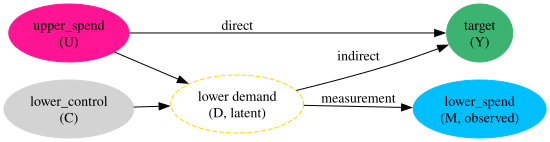

In [1]:
import graphviz as gr

g = gr.Digraph()
g.attr(rankdir="LR")

g.node("U", "upper_spend\n(U)", color="deeppink", style="filled")
g.node("C", "lower_control\n(C)", color="lightgray", style="filled")
g.node("D", "lower demand\n(D, latent)", color="gold", style="dashed")
g.node("M", "lower_spend\n(M, observed)", color="deepskyblue", style="filled")
g.node("Y", "target\n(Y)", color="mediumseagreen", style="filled")

g.edge("U", "Y", label="direct")
g.edge("U", "D")
g.edge("C", "D")
g.edge("D", "M", label="measurement")
g.edge("D", "Y", label="indirect")

g

## Prepare Notebook

In [2]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from pydantic import InstanceOf
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import MuEffect
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = sum(map(ord, "funnel"))
rng: np.random.Generator = np.random.default_rng(seed=seed)


def hdi_bounds(da, prob: float = 0.94):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")

## The `FunnelEffect` component

`pymc-marketing`'s `MMM` builds the target mean as
$\mu = \text{baseline} + \sum \text{contributions}$ with a single likelihood.
A {class}`~pymc_marketing.mmm.additive_effect.MuEffect` is the sanctioned way to
add an arbitrary term to that mean. It follows a three-method protocol:

- `create_data(mmm)` -- register any `pymc.dims.Data` the effect needs.
- `create_effect(mmm)` -- return a tensor with dims `("date", *mmm.dims)` that is
  **added** to the target mean.
- `set_data(mmm, model, X)` -- refresh the data at prediction time.

The key move for funnel modeling is that `create_effect` runs *inside* the model
context, so nothing stops it from declaring **its own observed likelihood**. That
turns "add a term to `mu`" into "fit a second structural equation jointly with the
target". Our `FunnelEffect` does exactly that:

1. It reads the (scaled) upper-funnel spend already registered by the base `MMM`.
2. It builds the latent lower-funnel **demand** from upper spend (with its own
   adstock + saturation) plus a baseline and the exogenous control.
3. It attaches a **second likelihood** for the observed lower-funnel spend to that
   demand.
4. It returns the lower-funnel $\to$ target contribution (with a *second* adstock
   + saturation) to be added to the target mean.

Because the target consumes the **latent demand** -- not the observed lower spend
-- this is a genuine structural mediation, and interventions on `upper_spend`
propagate through the mediator automatically.

In [4]:
class FunnelEffect(MuEffect):
    """Upper- to lower-funnel mediation with its own likelihood.

    Encodes the indirect path ``upper_spend -> lower_demand -> target`` as an
    additive effect on the target mean, while jointly fitting the lower-funnel
    spend through a second (truncated normal) likelihood.
    """

    prefix: str = "funnel"
    lower_spend: list[float]
    lower_control: list[float]
    adstock_uf: InstanceOf[GeometricAdstock]
    saturation_uf: InstanceOf[LogisticSaturation]
    adstock_lf: InstanceOf[GeometricAdstock]
    saturation_lf: InstanceOf[LogisticSaturation]

    def to_dict(self) -> dict:
        """Serialize the effect (media transforms delegate to their own dicts)."""
        return {
            "prefix": self.prefix,
            "lower_spend": list(self.lower_spend),
            "lower_control": list(self.lower_control),
            "adstock_uf": self.adstock_uf.to_dict(),
            "saturation_uf": self.saturation_uf.to_dict(),
            "adstock_lf": self.adstock_lf.to_dict(),
            "saturation_lf": self.saturation_lf.to_dict(),
        }

    def create_data(self, mmm) -> None:
        """Register the observed lower-funnel spend and the exogenous control."""
        pmd.Data(
            f"{self.prefix}_lower_spend",
            np.asarray(self.lower_spend, dtype=float),
            dims=("date",),
        )
        pmd.Data(
            f"{self.prefix}_control",
            np.asarray(self.lower_control, dtype=float),
            dims=("date",),
        )

    def create_effect(self, mmm):
        """Build the mediator equation (+ its likelihood) and return the effect."""
        model = mmm.model
        # Reuse the scaled upper-funnel spend already built by the base MMM.
        upper = mmm.channel_data_scaled.isel(channel=0)

        # Structural equation 1: upper spend -> latent lower-funnel demand.
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0)
        upper_on_lower = self.saturation_uf.apply(
            self.adstock_uf.apply(upper, core_dim="date"), core_dim="date"
        )
        demand = pmd.Deterministic(
            f"{self.prefix}_lower_demand",
            baseline + gamma * model[f"{self.prefix}_control"] + upper_on_lower,
        )

        # Second likelihood: observed lower-funnel spend around latent demand.
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_likelihood",
            mu=demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma", sigma=1.0),
            lower=0.0,
            observed=model[f"{self.prefix}_lower_spend"],
        )

        # Structural equation 2: latent demand -> target contribution.
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.saturation_lf.apply(
                self.adstock_lf.apply(demand, core_dim="date"), core_dim="date"
            ),
        )

    def set_data(self, mmm, model, X) -> None:
        """Refresh the effect's data at prediction time."""
        pm.set_data(
            {
                f"{self.prefix}_lower_spend": np.asarray(self.lower_spend, dtype=float),
                f"{self.prefix}_control": np.asarray(self.lower_control, dtype=float),
            },
            model=model,
        )

## Data generating process

We follow the same recipe as the {ref}`mmm_data_generator` notebook: build a PyMC
model, clamp the parameters to known ground-truth values with the
[`do`](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model.transform.conditioning.do.html)
operator, and forward-sample. The twist here is that the generative model **is**
the funnel MMM (base `MMM` + `FunnelEffect`), so a single forward pass produces
**both** the observed lower-funnel spend and the target.

### Configuration

In [5]:
n_dates = 130
l_max = 8

date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)
coords = {"date": date_range}

### Exogenous covariates

We draw `upper_spend` and `lower_control` from a small PyMC model with an LKJ
prior on the (near-diagonal) correlation structure and a `softplus` transform to
keep spend non-negative. We deliberately make the two drivers close to
independent: the control is an *exogenous* source of lower-funnel variation, which
is what identifies the mediator equation separately from the direct path.

In [6]:
t = np.arange(n_dates) / n_dates
cov_coords = {"date": date_range, "driver": ["upper_spend", "lower_control"]}

with pm.Model(coords=cov_coords) as covariates_model:
    t_data = pm.Data("t", t, dims=("date",))
    L, _, _ = pm.LKJCholeskyCov("L", n=2, eta=100, sd_dist=pm.Exponential.dist(lam=1.0))
    a = pm.Normal("a", mu=0, sigma=1, dims="driver")
    b = pm.Normal("b", mu=0, sigma=1, dims="driver")
    mu_cov = pm.Deterministic(
        "mu_cov", a + b * t_data[..., None], dims=("date", "driver")
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "driver"))

In [7]:
x_data = pm.draw(covariates_model.x, draws=1, random_seed=rng)

df = pd.DataFrame(
    {
        "date": date_range,
        "upper_spend": x_data[:, 0],
        "lower_control": x_data[:, 1],
        "lower_spend_dummy": np.ones(n_dates),
        "y_dummy": np.ones(n_dates),
    }
)
df.head()

,date,upper_spend,lower_control,lower_spend_dummy,y_dummy
0,2021-01-04,0.204664,0.936577,1.0,1.0
1,2021-01-11,1.966219,1.587323,1.0,1.0
2,2021-01-18,1.196404,1.353986,1.0,1.0
3,2021-01-25,0.067877,0.572868,1.0,1.0
4,2021-02-01,0.560784,0.703662,1.0,1.0


### Ground-truth parameters

We fix explicit true values for every structural parameter. Splitting the effect
of upper spend across a direct and an indirect path is the whole point, so we pick
values where **both paths carry meaningful weight**.

In [8]:
true = {
    "intercept_contribution": 0.25,
    # direct path: upper -> target
    "adstock_alpha": 0.45,
    "saturation_lam": 4.0,
    "saturation_beta": 0.80,
    "y_sigma": 0.05,
    # mediator equation: upper -> lower-funnel demand
    "funnel_baseline": 0.15,
    "funnel_gamma": 0.25,
    "adstock_uf_alpha": 0.50,
    "sat_uf_lam": 2.5,
    "sat_uf_beta": 1.3,
    "funnel_sigma": 0.04,
    # lower-funnel path: lower demand -> target
    "adstock_lf_alpha": 0.30,
    "sat_lf_lam": 1.2,
    "sat_lf_beta": 1.1,
}
true = {k: np.asarray(v, dtype=float) for k, v in true.items()}

In [9]:
def make_funnel_effect(lower_spend, lower_control):
    """Construct a FunnelEffect with fresh, uniquely-prefixed media transforms."""
    return FunnelEffect(
        lower_spend=list(np.asarray(lower_spend, dtype=float)),
        lower_control=list(np.asarray(lower_control, dtype=float)),
        adstock_uf=GeometricAdstock(l_max=l_max, prefix="adstock_uf"),
        saturation_uf=LogisticSaturation(prefix="sat_uf"),
        adstock_lf=GeometricAdstock(l_max=l_max, prefix="adstock_lf"),
        saturation_lf=LogisticSaturation(prefix="sat_lf"),
    )

### Forward simulation

We build the funnel MMM on the dummy target, register original-scale contribution
variables (so we can read off the true decomposition), clamp the parameters to
their true values, and forward-sample. The base `MMM` supplies the intercept and
the **direct** upper $\to$ target contribution; the `FunnelEffect` supplies the
mediator likelihood and the **indirect** contribution.

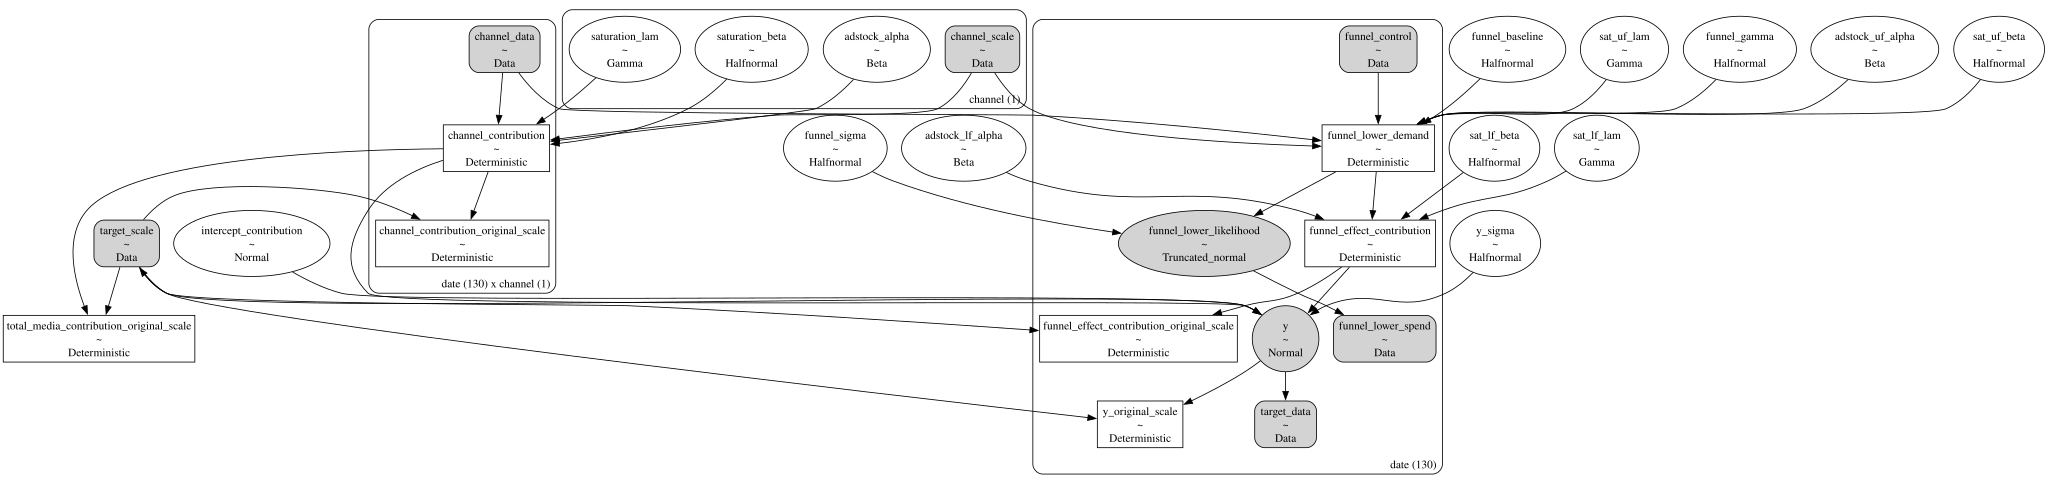

In [10]:
model_config_gen = {
    "intercept": Prior("Normal", mu=0.3, sigma=0.1),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.1)),
}

gen = MMM(
    date_column="date",
    target_column="y_dummy",
    channel_columns=["upper_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    model_config=model_config_gen,
)
gen.add_mu_effect(make_funnel_effect(df["lower_spend_dummy"], df["lower_control"]))

X_gen = df[["date", "upper_spend"]]
gen.build_model(X_gen, df["y_dummy"])
gen.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)

pm.model_to_graphviz(gen.model)

The graph above makes the two likelihoods explicit: `funnel_lower_likelihood`
(observed lower-funnel spend) and `y` (the target) are both children of the same
set of latent parameters. Now we clamp the parameters and forward-sample. Note
that the two channel-dimensioned direct-path parameters need a length-1 array.

In [11]:
channel_dim_vars = {"adstock_alpha", "saturation_lam", "saturation_beta"}
intervention = {
    k: (true[k].reshape(1) if k in channel_dim_vars else true[k]) for k in true
}
gen.model = do(gen.model, intervention)

In [12]:
with gen.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1,
        var_names=[
            "y_original_scale",
            "channel_contribution_original_scale",
            "funnel_effect_contribution_original_scale",
            "funnel_lower_likelihood",
        ],
        random_seed=rng,
    )

prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior["y_original_scale"].to_numpy().ravel()
lower_spend_obs = prior_pp["funnel_lower_likelihood"].to_numpy().ravel()
direct_true = (
    prior["channel_contribution_original_scale"].isel(channel=0).to_numpy().ravel()
)
indirect_raw = prior["funnel_effect_contribution_original_scale"].to_numpy().ravel()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_likelihood, y]


The raw `funnel_effect_contribution` includes the part of lower-funnel demand that
comes from the baseline and the control -- not from upper spend. To isolate the
**causal** contribution of upper spend through the mediator, we re-run the clamped
generative model with `upper_spend` set to zero and subtract.

In [13]:
with gen.model:
    pm.set_data({"channel_data": np.zeros((n_dates, 1))})
    idata_cf = pm.sample_prior_predictive(
        draws=1,
        var_names=["y_original_scale", "funnel_effect_contribution_original_scale"],
        random_seed=rng,
    )

prior_cf = idata_cf["prior"].sel(chain=0, draw=0)
indirect_upper0 = (
    prior_cf["funnel_effect_contribution_original_scale"].to_numpy().ravel()
)

# Restore the generative model's upper-funnel spend.
with gen.model:
    pm.set_data({"channel_data": df[["upper_spend"]].to_numpy()})

indirect_true = indirect_raw - indirect_upper0  # causal indirect contribution
total_upper_true = direct_true + indirect_true

Sampling: [y]


In [14]:
df["y_obs"] = y_obs
df["lower_spend"] = lower_spend_obs
df["direct_true"] = direct_true
df["indirect_true"] = indirect_true
df["total_upper_true"] = total_upper_true

# Drop the first ``l_max`` rows: the adstock transform needs a burn-in window.
df = df.tail(-l_max).reset_index(drop=True)

share = df["indirect_true"].mean() / df["total_upper_true"].mean()
print(f"Mean direct contribution:   {df['direct_true'].mean():.3f}")
print(f"Mean indirect contribution: {df['indirect_true'].mean():.3f}")
print(f"Indirect share of upper-funnel effect: {share:.1%}")
df.head()

Mean direct contribution:   0.335
Mean indirect contribution: 0.199
Indirect share of upper-funnel effect: 37.2%


,date,upper_spend,lower_control,lower_spend_dummy,y_dummy,y_obs,lower_spend,direct_true,indirect_true,total_upper_true
0,2021-03-01,0.018898,1.202925,1.0,1.0,0.581179,0.497827,0.063864,0.051634,0.115498
1,2021-03-08,1.458776,1.691106,1.0,1.0,0.863601,0.807176,0.222916,0.102511,0.325427
2,2021-03-15,2.441249,0.987102,1.0,1.0,1.143889,0.762176,0.399293,0.195352,0.594646
3,2021-03-22,0.004147,0.690200,1.0,1.0,0.859813,0.430669,0.193942,0.150145,0.344087
4,2021-03-29,0.120347,1.127780,1.0,1.0,0.669259,0.540130,0.104861,0.095827,0.200688


### Exploratory visualization

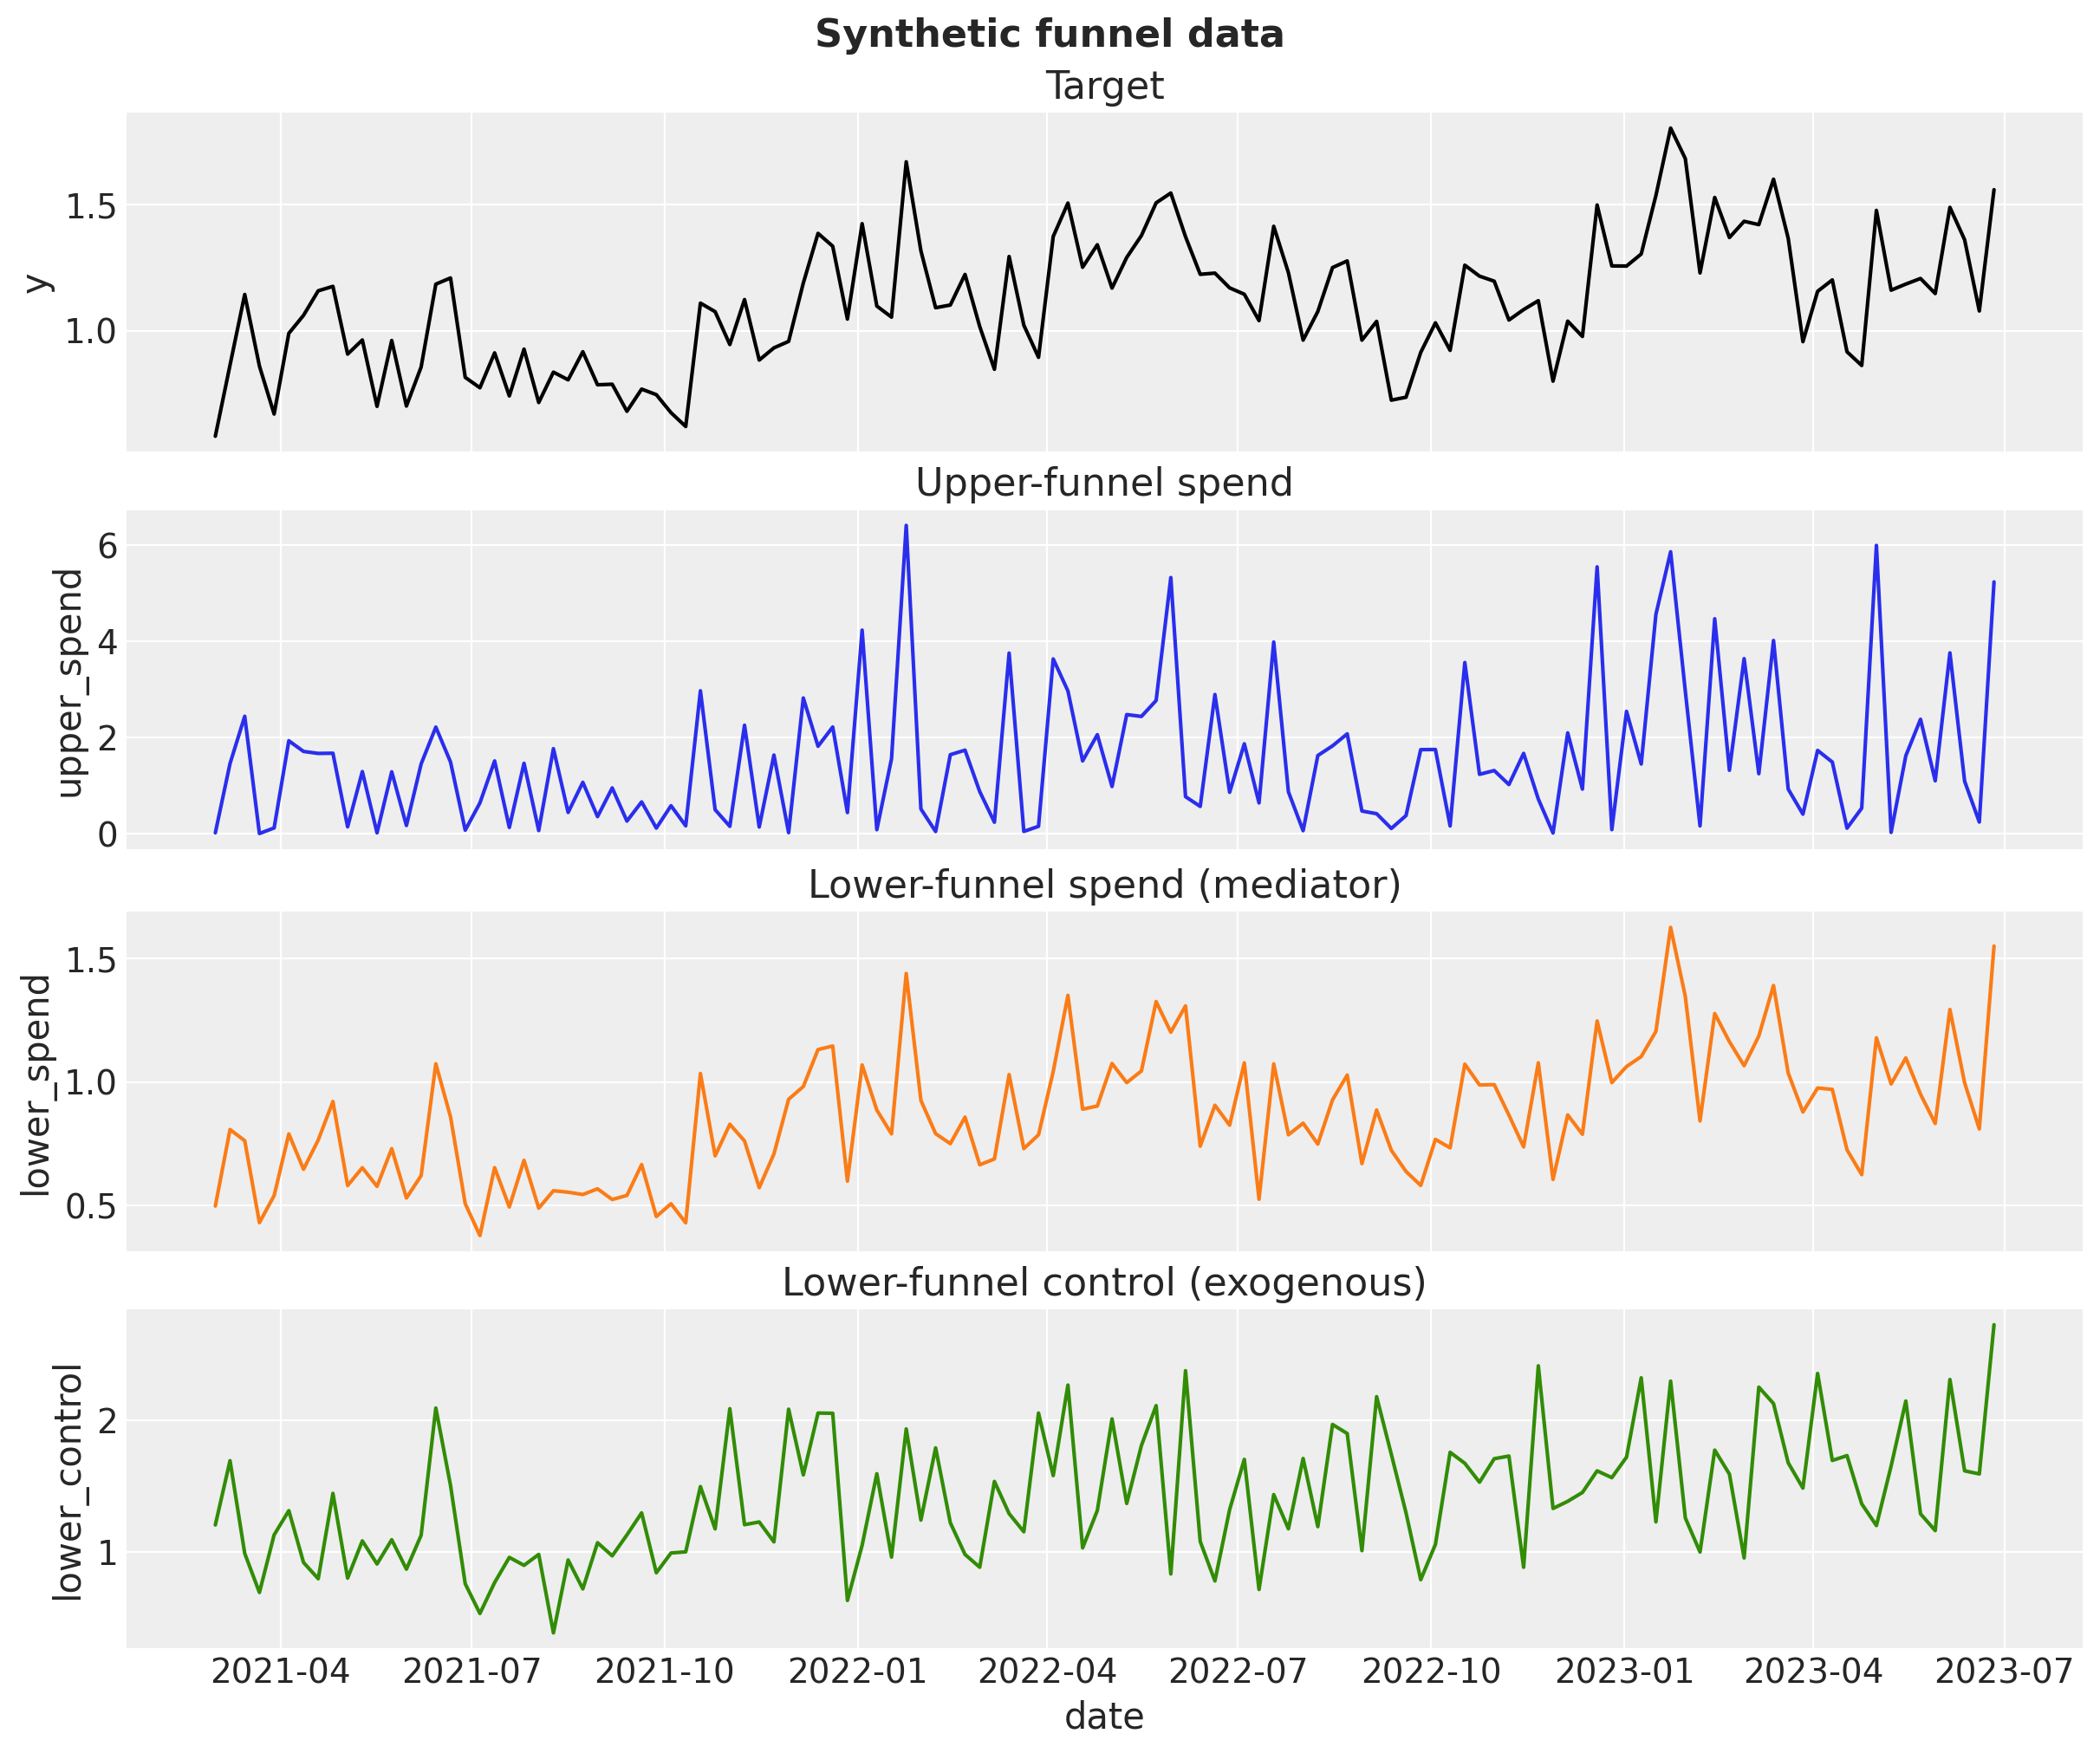

In [15]:
fig, ax = plt.subplots(nrows=4, figsize=(12, 10), sharex=True)

sns.lineplot(x="date", y="y_obs", data=df, color="black", ax=ax[0])
ax[0].set(title="Target", ylabel="y")
sns.lineplot(x="date", y="upper_spend", data=df, color="C0", ax=ax[1])
ax[1].set(title="Upper-funnel spend", ylabel="upper_spend")
sns.lineplot(x="date", y="lower_spend", data=df, color="C1", ax=ax[2])
ax[2].set(title="Lower-funnel spend (mediator)", ylabel="lower_spend")
sns.lineplot(x="date", y="lower_control", data=df, color="C2", ax=ax[3])
ax[3].set(title="Lower-funnel control (exogenous)", ylabel="lower_control")
fig.suptitle("Synthetic funnel data", fontsize=16, fontweight="bold");

The true decomposition of upper-funnel spend into its direct and indirect
(mediated) contributions -- this is the ground truth the models will try to
recover.

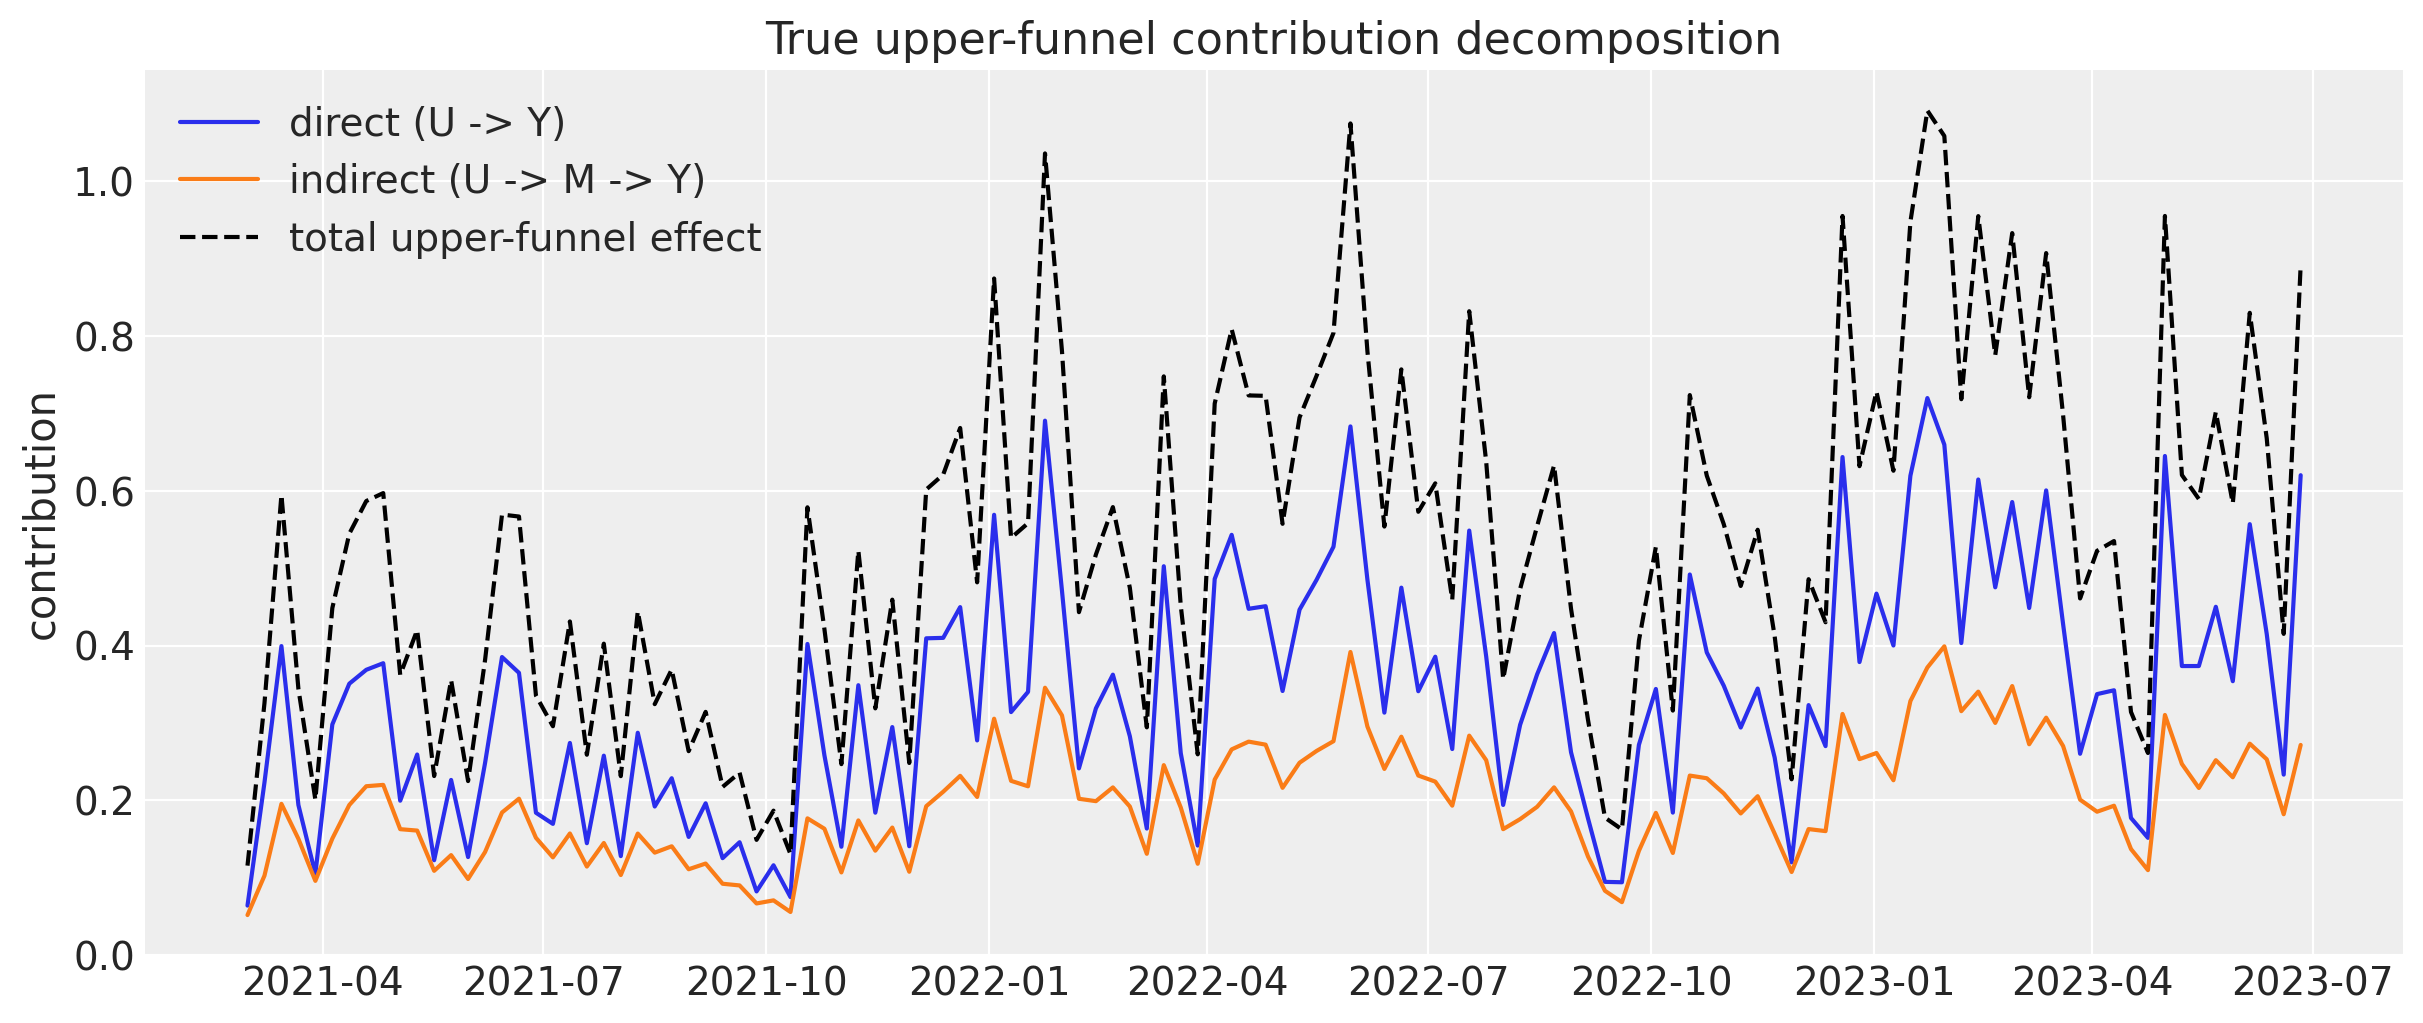

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["direct_true"], label="direct (U -> Y)", color="C0")
ax.plot(df["date"], df["indirect_true"], label="indirect (U -> M -> Y)", color="C1")
ax.plot(
    df["date"],
    df["total_upper_true"],
    label="total upper-funnel effect",
    color="black",
    linestyle="--",
)
ax.legend(loc="upper left")
ax.set(title="True upper-funnel contribution decomposition", ylabel="contribution");

## Fitting the models

We now fit three models on the synthetic data:

- **Naive A** -- a standard MMM with the mediator included as an **ordinary
  channel** (`upper_spend` and `lower_spend` side by side).
- **Naive B** -- a standard MMM with the mediator **omitted** (`upper_spend`
  only).
- **Funnel** -- the joint model with the `FunnelEffect`.

All three use the same adstock/saturation families and the same sampler settings.

In [17]:
X = df[["date", "upper_spend", "lower_spend"]]
y = df["y_obs"]

sample_kwargs = dict(
    chains=4, tune=1_000, draws=1_000, target_accept=0.9, random_seed=rng
)
sampler_config = {"nuts_sampler": "nutpie"}

### Naive A: mediator as an ordinary channel

This is what most production MMMs do when they have both upper- and lower-funnel
spend: drop them side by side as independent channels. Conditioning on the
mediator **blocks the indirect path**, so `upper_spend` is credited with (at most)
its direct effect, and the lower-funnel channel is over-credited with demand that
upper-funnel activity created.

In [18]:
naive_a = MMM(
    date_column="date",
    target_column="y_obs",
    channel_columns=["upper_spend", "lower_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    sampler_config=sampler_config,
)
naive_a.build_model(X, y)
naive_a.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_a.fit(X, y, **sample_kwargs)
naive_a.sample_posterior_predictive(X, random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive B: mediator omitted

Here `upper_spend` is the only channel. Its response curve is forced to absorb
*both* the direct effect and the demand it creates downstream, with no separate
lower-funnel lever. Because the mediator is gone, that single curve also has to
soak up the exogenous, control-driven fluctuations in lower-funnel demand that
move the target but are unrelated to upper spend, with nowhere else to attribute
them. Fitting one saturation curve to this composite relationship generally
biases the upper-funnel estimate -- here, upward.

In [19]:
naive_b = MMM(
    date_column="date",
    target_column="y_obs",
    channel_columns=["upper_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    sampler_config=sampler_config,
)
naive_b.build_model(X[["date", "upper_spend"]], y)
naive_b.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_b.fit(X[["date", "upper_spend"]], y, **sample_kwargs)
naive_b.sample_posterior_predictive(X[["date", "upper_spend"]], random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### The funnel model

The funnel model has `upper_spend` as its only channel (its direct effect) plus
the `FunnelEffect`, which is fed the **real** generated lower-funnel spend and
control. It fits the lower-funnel spend and the target jointly.

In [20]:
funnel = MMM(
    date_column="date",
    target_column="y_obs",
    channel_columns=["upper_spend"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    sampler_config=sampler_config,
)
funnel.add_mu_effect(make_funnel_effect(df["lower_spend"], df["lower_control"]))
funnel.build_model(X[["date", "upper_spend"]], y)
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)
funnel.fit(X[["date", "upper_spend"]], y, **sample_kwargs)
funnel.sample_posterior_predictive(X[["date", "upper_spend"]], random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_likelihood, y]


Output()

### Diagnostics

In [21]:
for label, m in [("Naive A", naive_a), ("Naive B", naive_b), ("Funnel", funnel)]:
    divergences = int(m.idata["sample_stats"]["diverging"].sum())
    max_rhat = float(az.summary(m.idata)["r_hat"].max())
    print(f"{label:8s} | divergences: {divergences:3d} | max r-hat: {max_rhat:.3f}")

Naive A  | divergences:   0 | max r-hat: 1.020
Naive B  | divergences:   0 | max r-hat: 1.000
Funnel   | divergences:   0 | max r-hat: 1.010


### Posterior predictive checks

The funnel model has **two** observed quantities. Both should be well recovered:
the target and the lower-funnel spend.

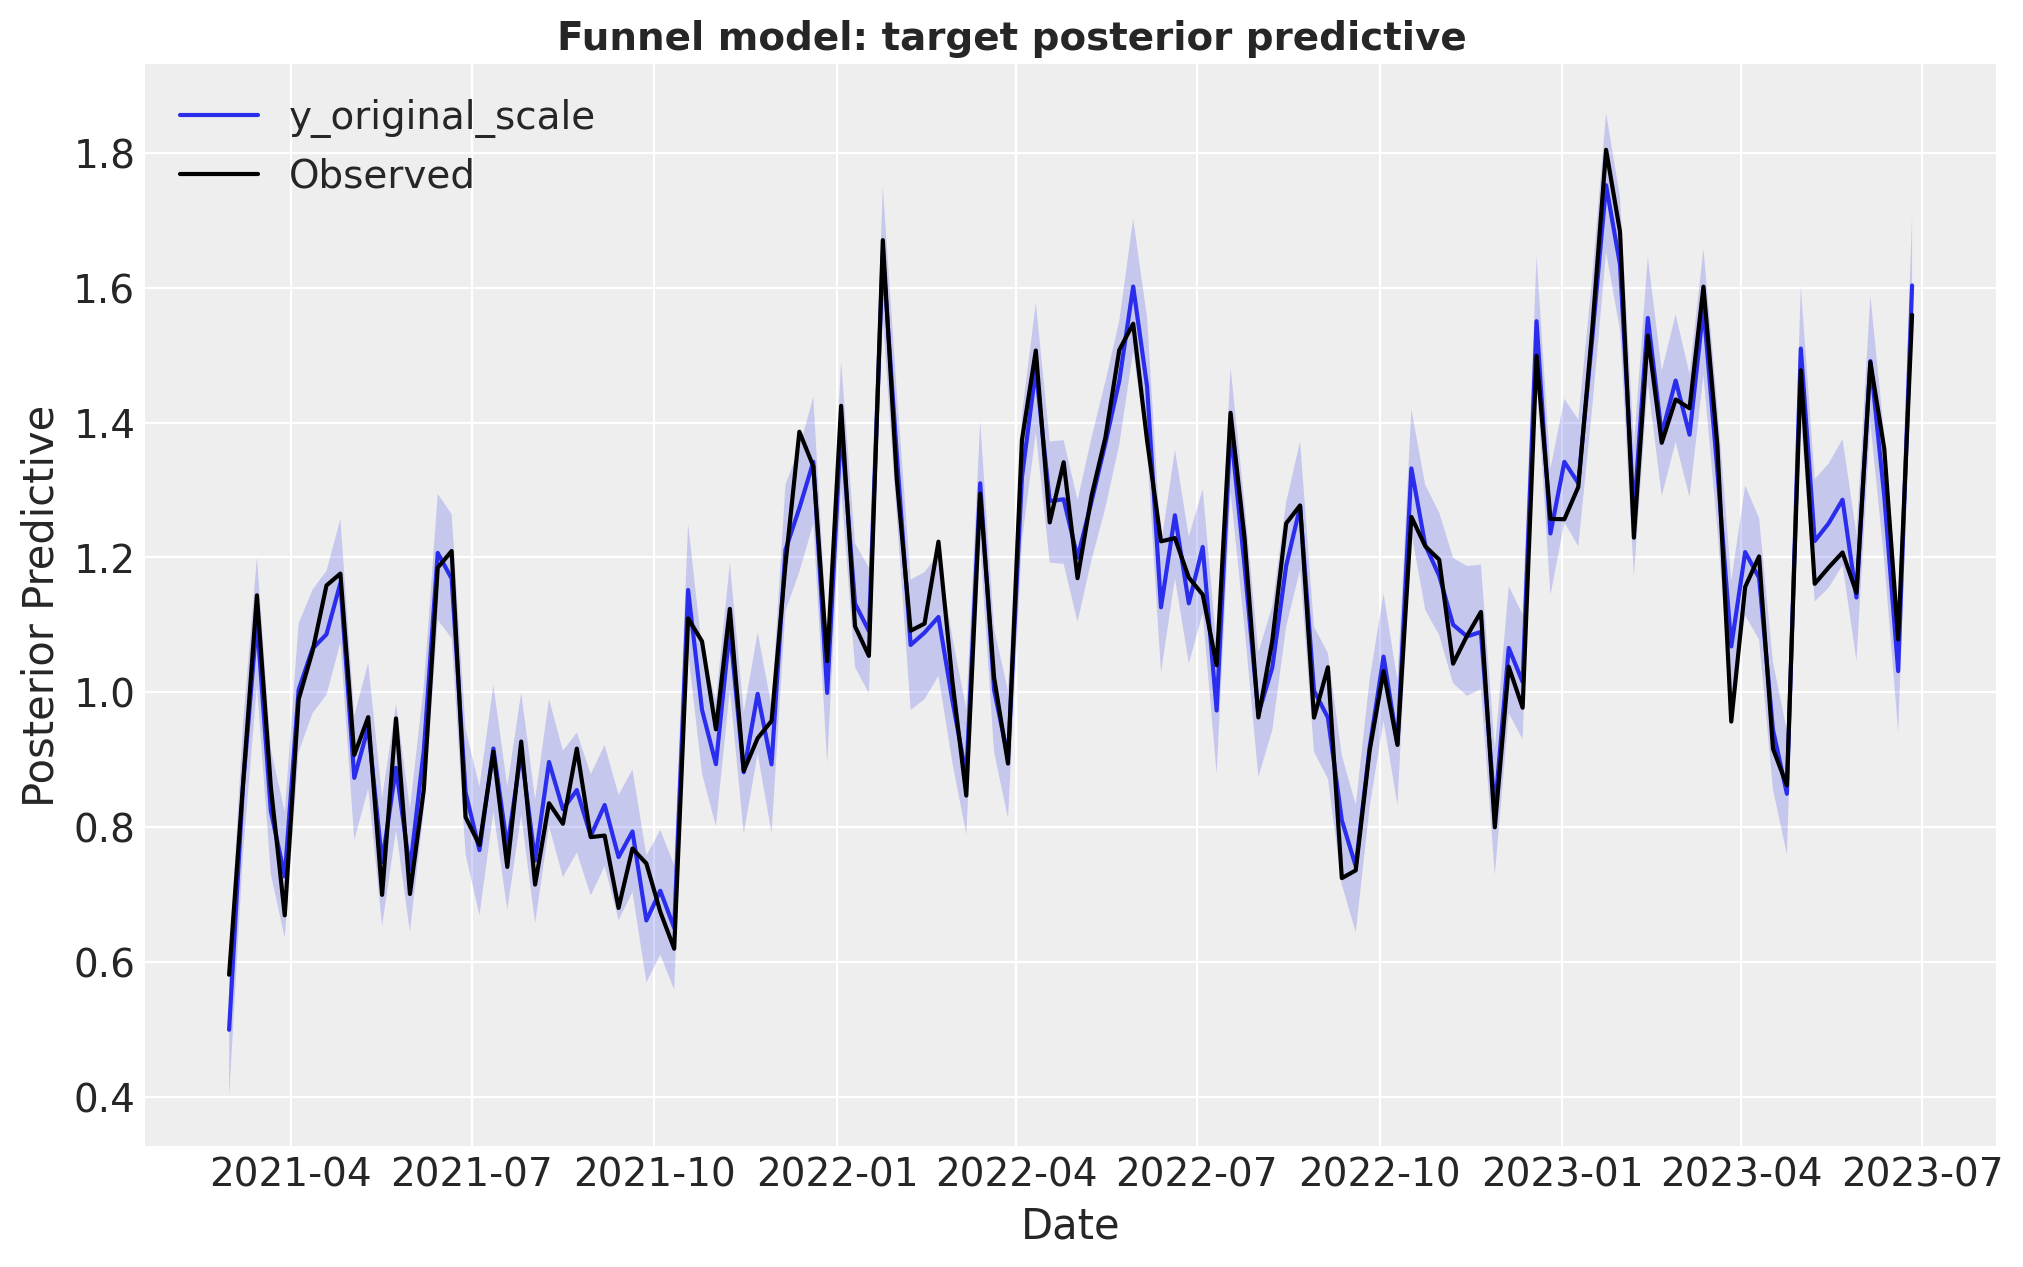

In [22]:
funnel.plot_suite = "new"
fig, axes = funnel.plot.diagnostics.posterior_predictive(hdi_prob=0.94)
axes.flatten()[0].legend()
fig.suptitle(
    "Funnel model: target posterior predictive", fontsize=14, fontweight="bold", y=1.03
);

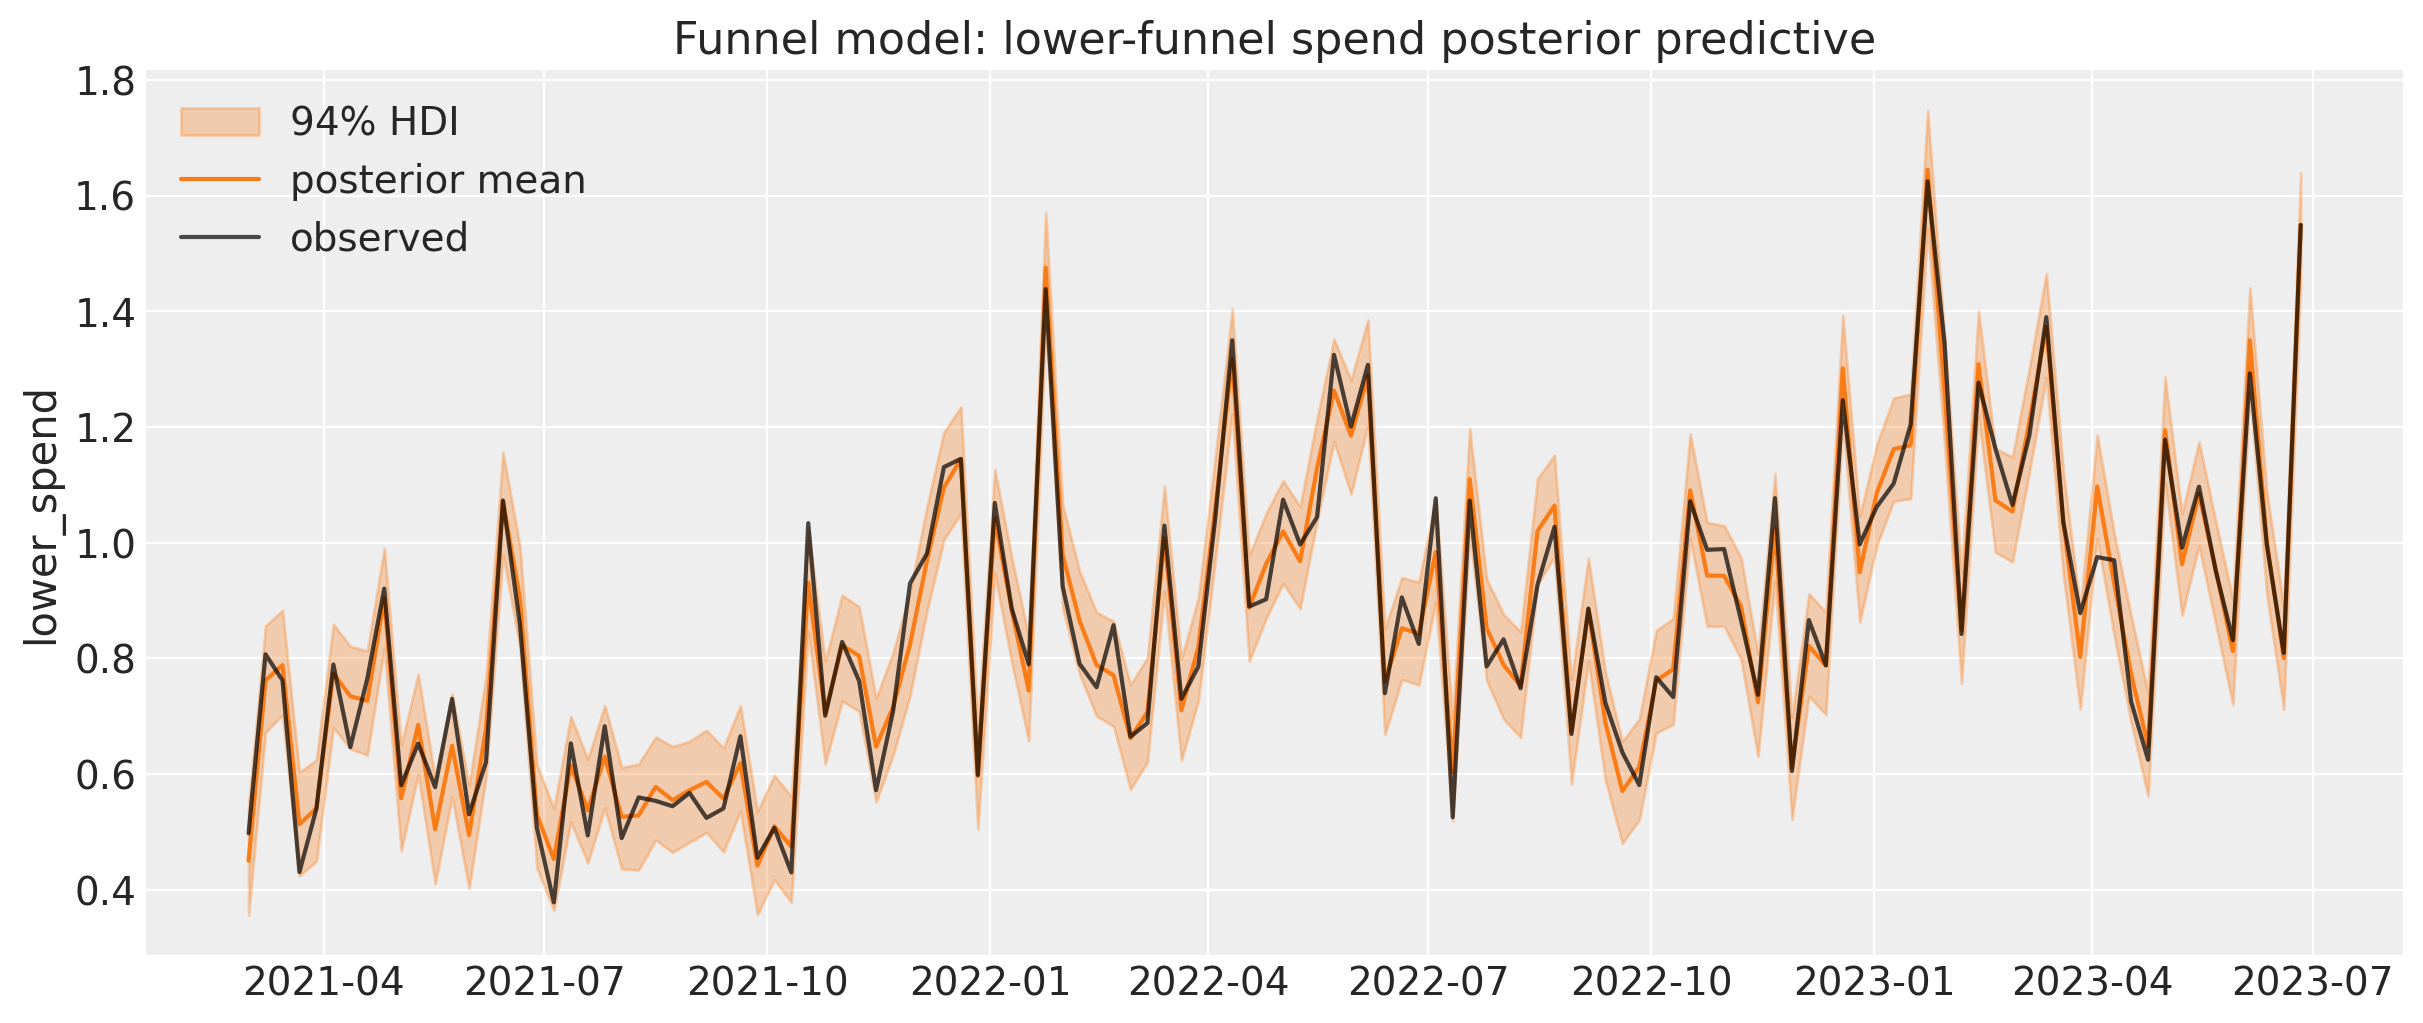

In [23]:
lower_pp = funnel.idata.posterior_predictive["funnel_lower_likelihood"]
lower_mean = lower_pp.mean(dim=[d for d in lower_pp.dims if d != "date"]).to_numpy()
lower_lo, lower_hi = hdi_bounds(lower_pp)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(
    df["date"],
    lower_lo,
    lower_hi,
    alpha=0.3,
    color="C1",
    label="94% HDI",
)
ax.plot(df["date"], lower_mean, color="C1", label="posterior mean")
ax.plot(df["date"], df["lower_spend"], color="black", label="observed", alpha=0.7)
ax.legend(loc="upper left")
ax.set(
    title="Funnel model: lower-funnel spend posterior predictive", ylabel="lower_spend"
);

## Parameter recovery

Because we generated the data, we can check whether the funnel model recovers the
true parameters. We overlay the true value (dashed line) on each posterior.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_68510/1468168177.py:31: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


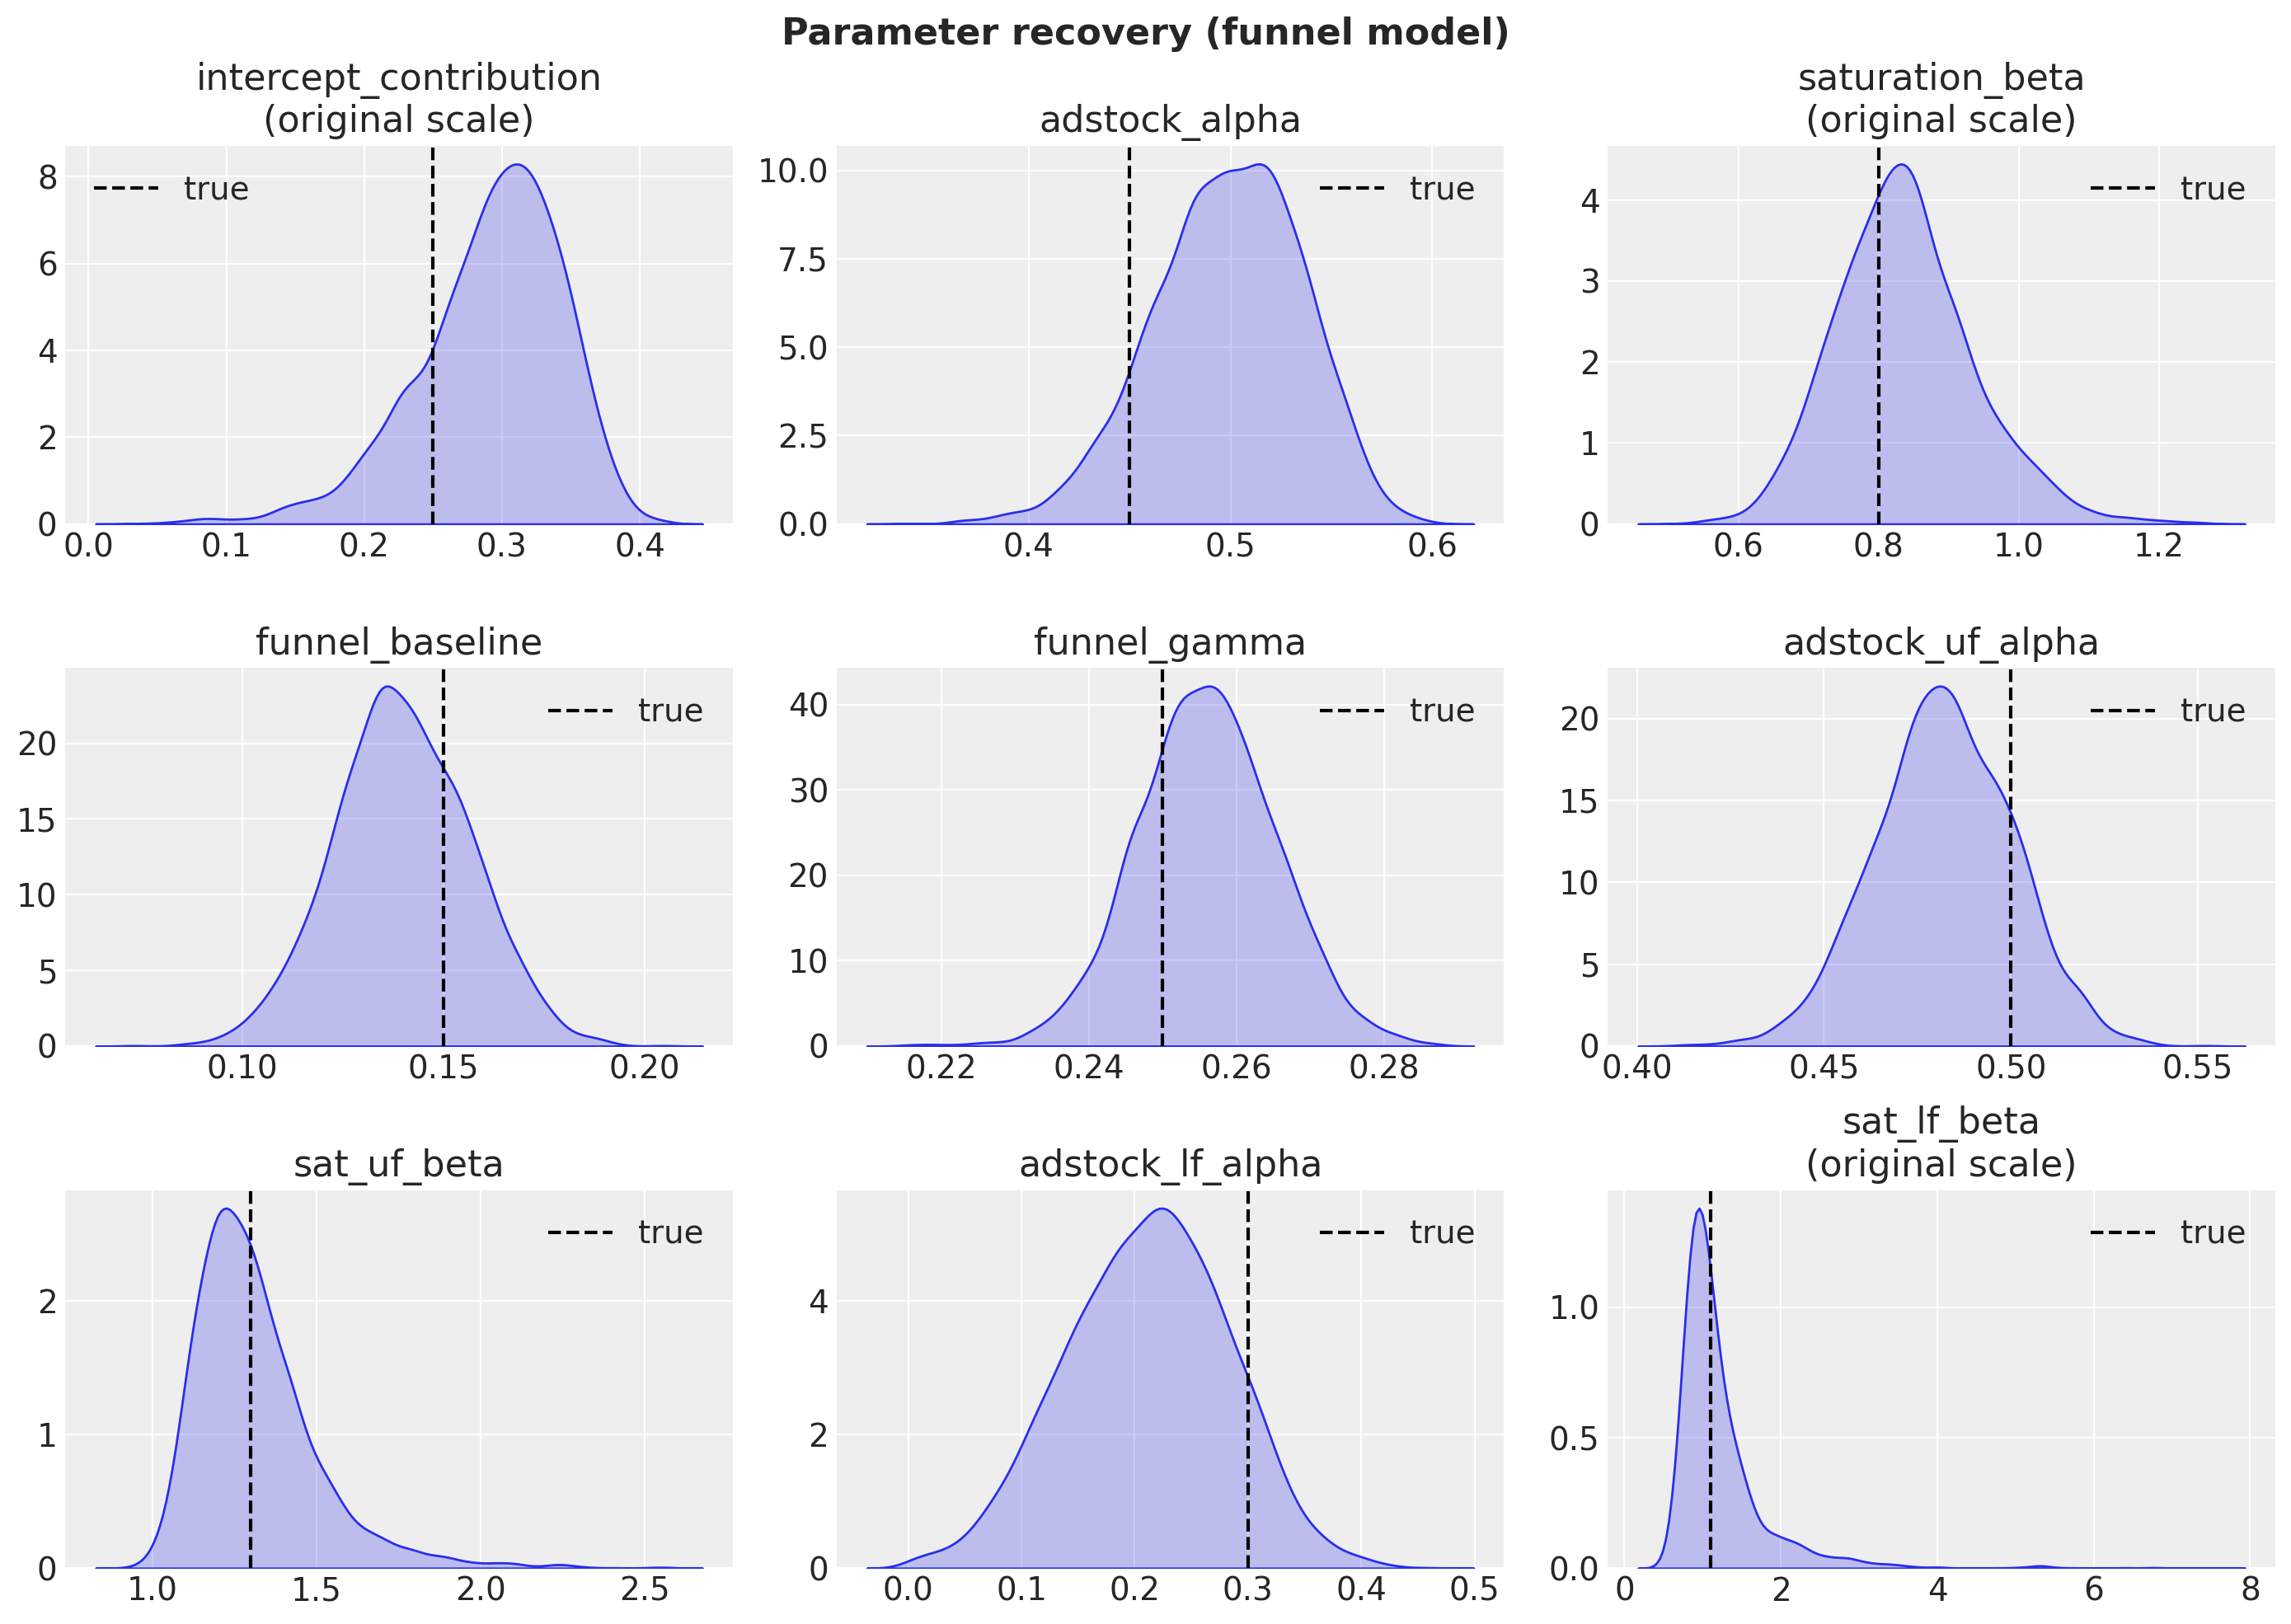

In [24]:
target_scale = float(funnel.idata.constant_data["target_scale"].squeeze())

# (title, variable, channel index, rescale to original target scale)
# Amplitude coefficients are fit on the internally scaled target, so they must be
# multiplied by target_scale before comparing against the ground-truth values.
recovery = [
    ("intercept_contribution", "intercept_contribution", None, True),
    ("adstock_alpha", "adstock_alpha", 0, False),
    ("saturation_beta", "saturation_beta", 0, True),
    ("funnel_baseline", "funnel_baseline", None, False),
    ("funnel_gamma", "funnel_gamma", None, False),
    ("adstock_uf_alpha", "adstock_uf_alpha", None, False),
    ("sat_uf_beta", "sat_uf_beta", None, False),
    ("adstock_lf_alpha", "adstock_lf_alpha", None, False),
    ("sat_lf_beta", "sat_lf_beta", None, True),
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))
for ax, (title, var, idx, rescale) in zip(axes.flatten(), recovery, strict=True):
    draws = funnel.idata.posterior[var]
    if idx is not None:
        draws = draws.isel({"channel": idx})
    if rescale:
        draws = draws * target_scale
        title = f"{title}\n(original scale)"
    sns.kdeplot(draws.to_numpy().ravel(), ax=ax, color="C0", fill=True)
    ax.axvline(float(true[var]), color="black", linestyle="--", label="true")
    ax.set(title=title, ylabel="")
    ax.legend()
fig.suptitle("Parameter recovery (funnel model)", fontsize=16, fontweight="bold")
fig.tight_layout();

Once the amplitude coefficients are expressed on the **original target scale**,
the parameters are recovered well. The apparent gap in the raw `saturation_beta`
(and in `intercept_contribution` and `sat_lf_beta`) is a **scaling artifact**, not
a modeling failure: the MMM standardizes its target internally (dividing by
`max(y)`), while the ground-truth values were defined on the unscaled target. The
raw posteriors therefore sit at roughly `true / target_scale`; multiplying by
`target_scale` puts them back on the ground-truth scale, where the true value
falls inside the bulk of each posterior. Parameters that act on the *inputs*
(adstock decays) or on the *raw mediator* (`funnel_baseline`, `funnel_gamma`,
`sat_uf_beta`, fit through the second likelihood on lower-funnel spend) are
scale-free and recover directly.

A separate, genuine effect remains: the **direct** upper $\to$ target saturation
and the **lower-funnel** saturation are only weakly identified *individually* --
both paths ultimately trace back to upper spend, so their split is not sharply
pinned down and those two posteriors stay comparatively wide even after
rescaling. As we will see next, the **total** upper-funnel effect is nonetheless
recovered accurately.

## Direct, indirect, and total effect

We reconstruct the funnel model's estimate of each path in original scale. The
direct path is the base channel contribution (which is already the counterfactual
versus zero spend, since saturation of zero is zero). The indirect path is the
mediated contribution **minus** what it would be with `upper_spend` set to zero.

In [25]:
X_zero = X[["date", "upper_spend"]].copy()
X_zero["upper_spend"] = 0.0

cf = funnel.sample_posterior_predictive(
    X_zero,
    extend_idata=False,
    combined=False,
    var_names=["funnel_effect_contribution_original_scale"],
    random_seed=rng,
)

direct_post = funnel.idata.posterior["channel_contribution_original_scale"].sel(
    channel="upper_spend"
)
indirect_post = (
    funnel.idata.posterior["funnel_effect_contribution_original_scale"]
    - cf["funnel_effect_contribution_original_scale"]
)
total_post = direct_post + indirect_post

Sampling: []


Output()

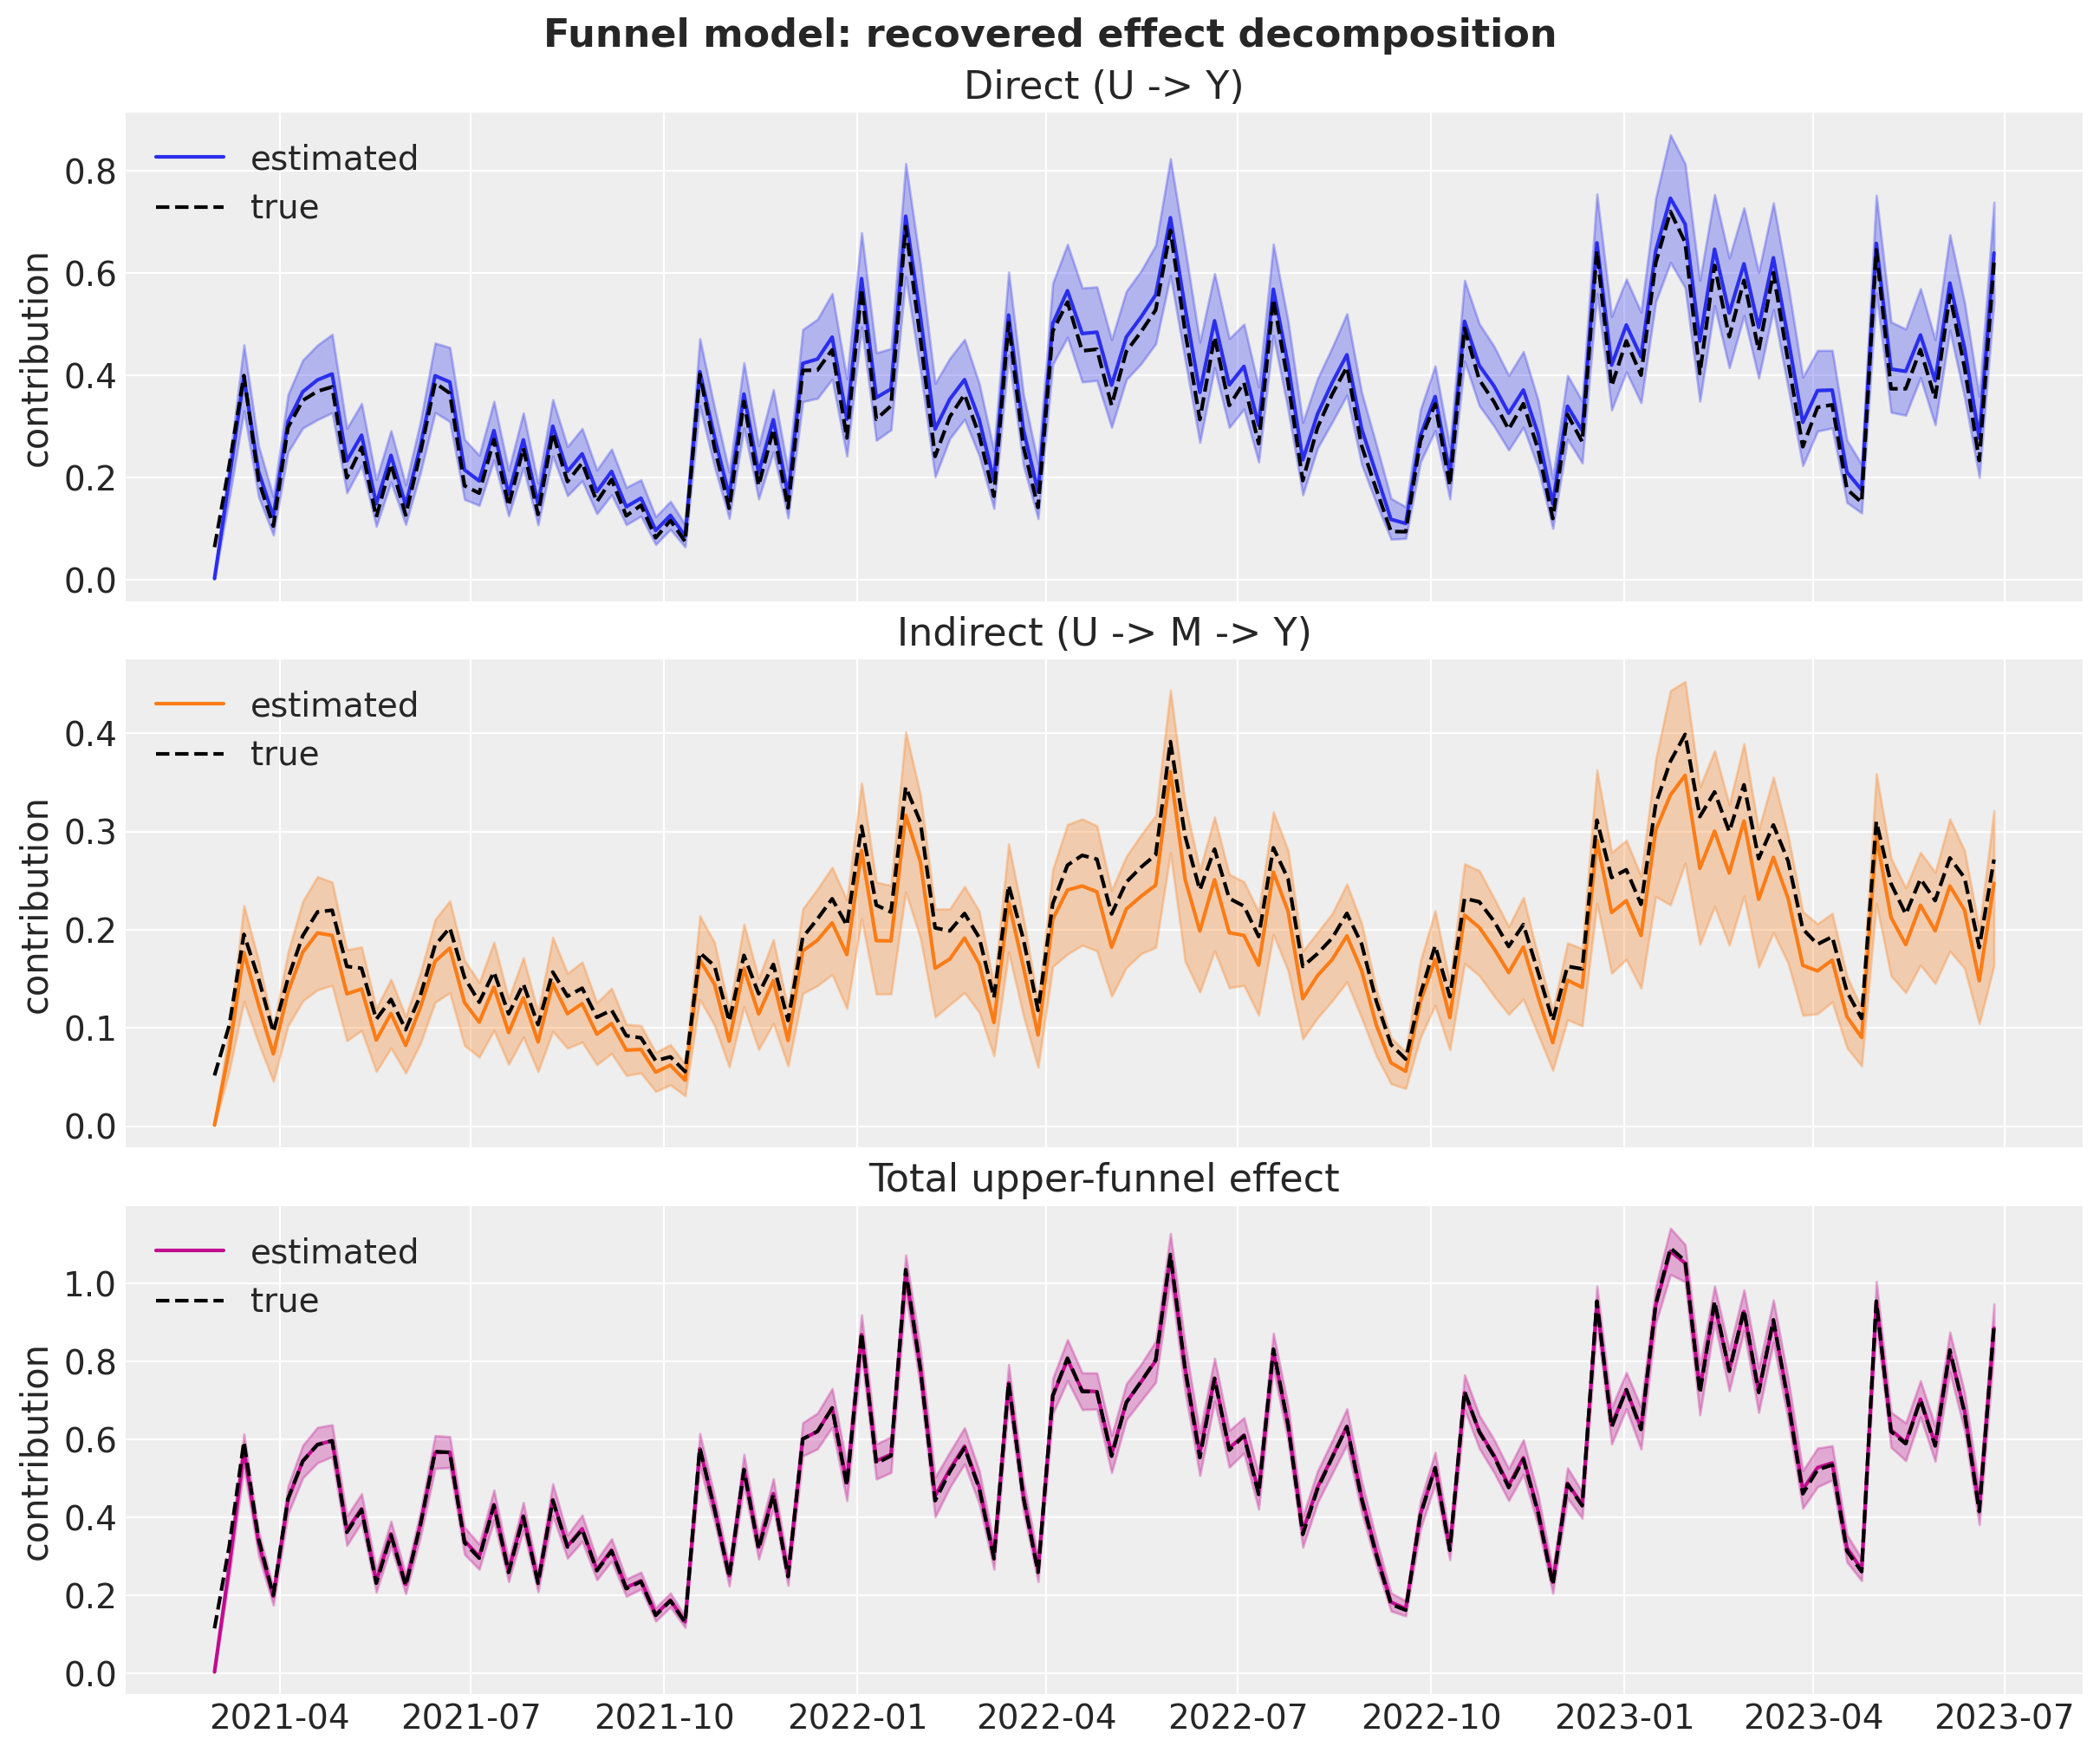

In [26]:
fig, axes = plt.subplots(nrows=3, figsize=(12, 10), sharex=True)
for ax, post, truth, title, color in [
    (axes[0], direct_post, "direct_true", "Direct (U -> Y)", "C0"),
    (axes[1], indirect_post, "indirect_true", "Indirect (U -> M -> Y)", "C1"),
    (axes[2], total_post, "total_upper_true", "Total upper-funnel effect", "C3"),
]:
    m = post.mean(dim=["chain", "draw"]).to_numpy()
    lo, hi = hdi_bounds(post)
    ax.fill_between(df["date"], lo, hi, alpha=0.3, color=color)
    ax.plot(df["date"], m, color=color, label="estimated")
    ax.plot(df["date"], df[truth], color="black", linestyle="--", label="true")
    ax.set(title=title, ylabel="contribution")
    ax.legend(loc="upper left")
fig.suptitle(
    "Funnel model: recovered effect decomposition", fontsize=16, fontweight="bold"
);

## Head-to-head: the bias from ignoring the funnel

Finally we compare the three models on the quantity a budget decision actually
depends on: the **total contribution of upper-funnel spend**. For the naive models
the upper channel contribution is already the counterfactual versus zero spend.
For the funnel model we use the direct plus (counterfactual) indirect contribution
computed above.

In [27]:
naive_a_upper = (
    naive_a.idata.posterior["channel_contribution_original_scale"]
    .sel(channel="upper_spend")
    .mean(dim="date")
)
naive_b_upper = (
    naive_b.idata.posterior["channel_contribution_original_scale"]
    .sel(channel="upper_spend")
    .mean(dim="date")
)
funnel_upper = total_post.mean(dim="date")

true_upper = float(df["total_upper_true"].mean())

estimates = {
    "Naive A\n(mediator as channel)": naive_a_upper,
    "Naive B\n(mediator omitted)": naive_b_upper,
    "Funnel": funnel_upper,
}

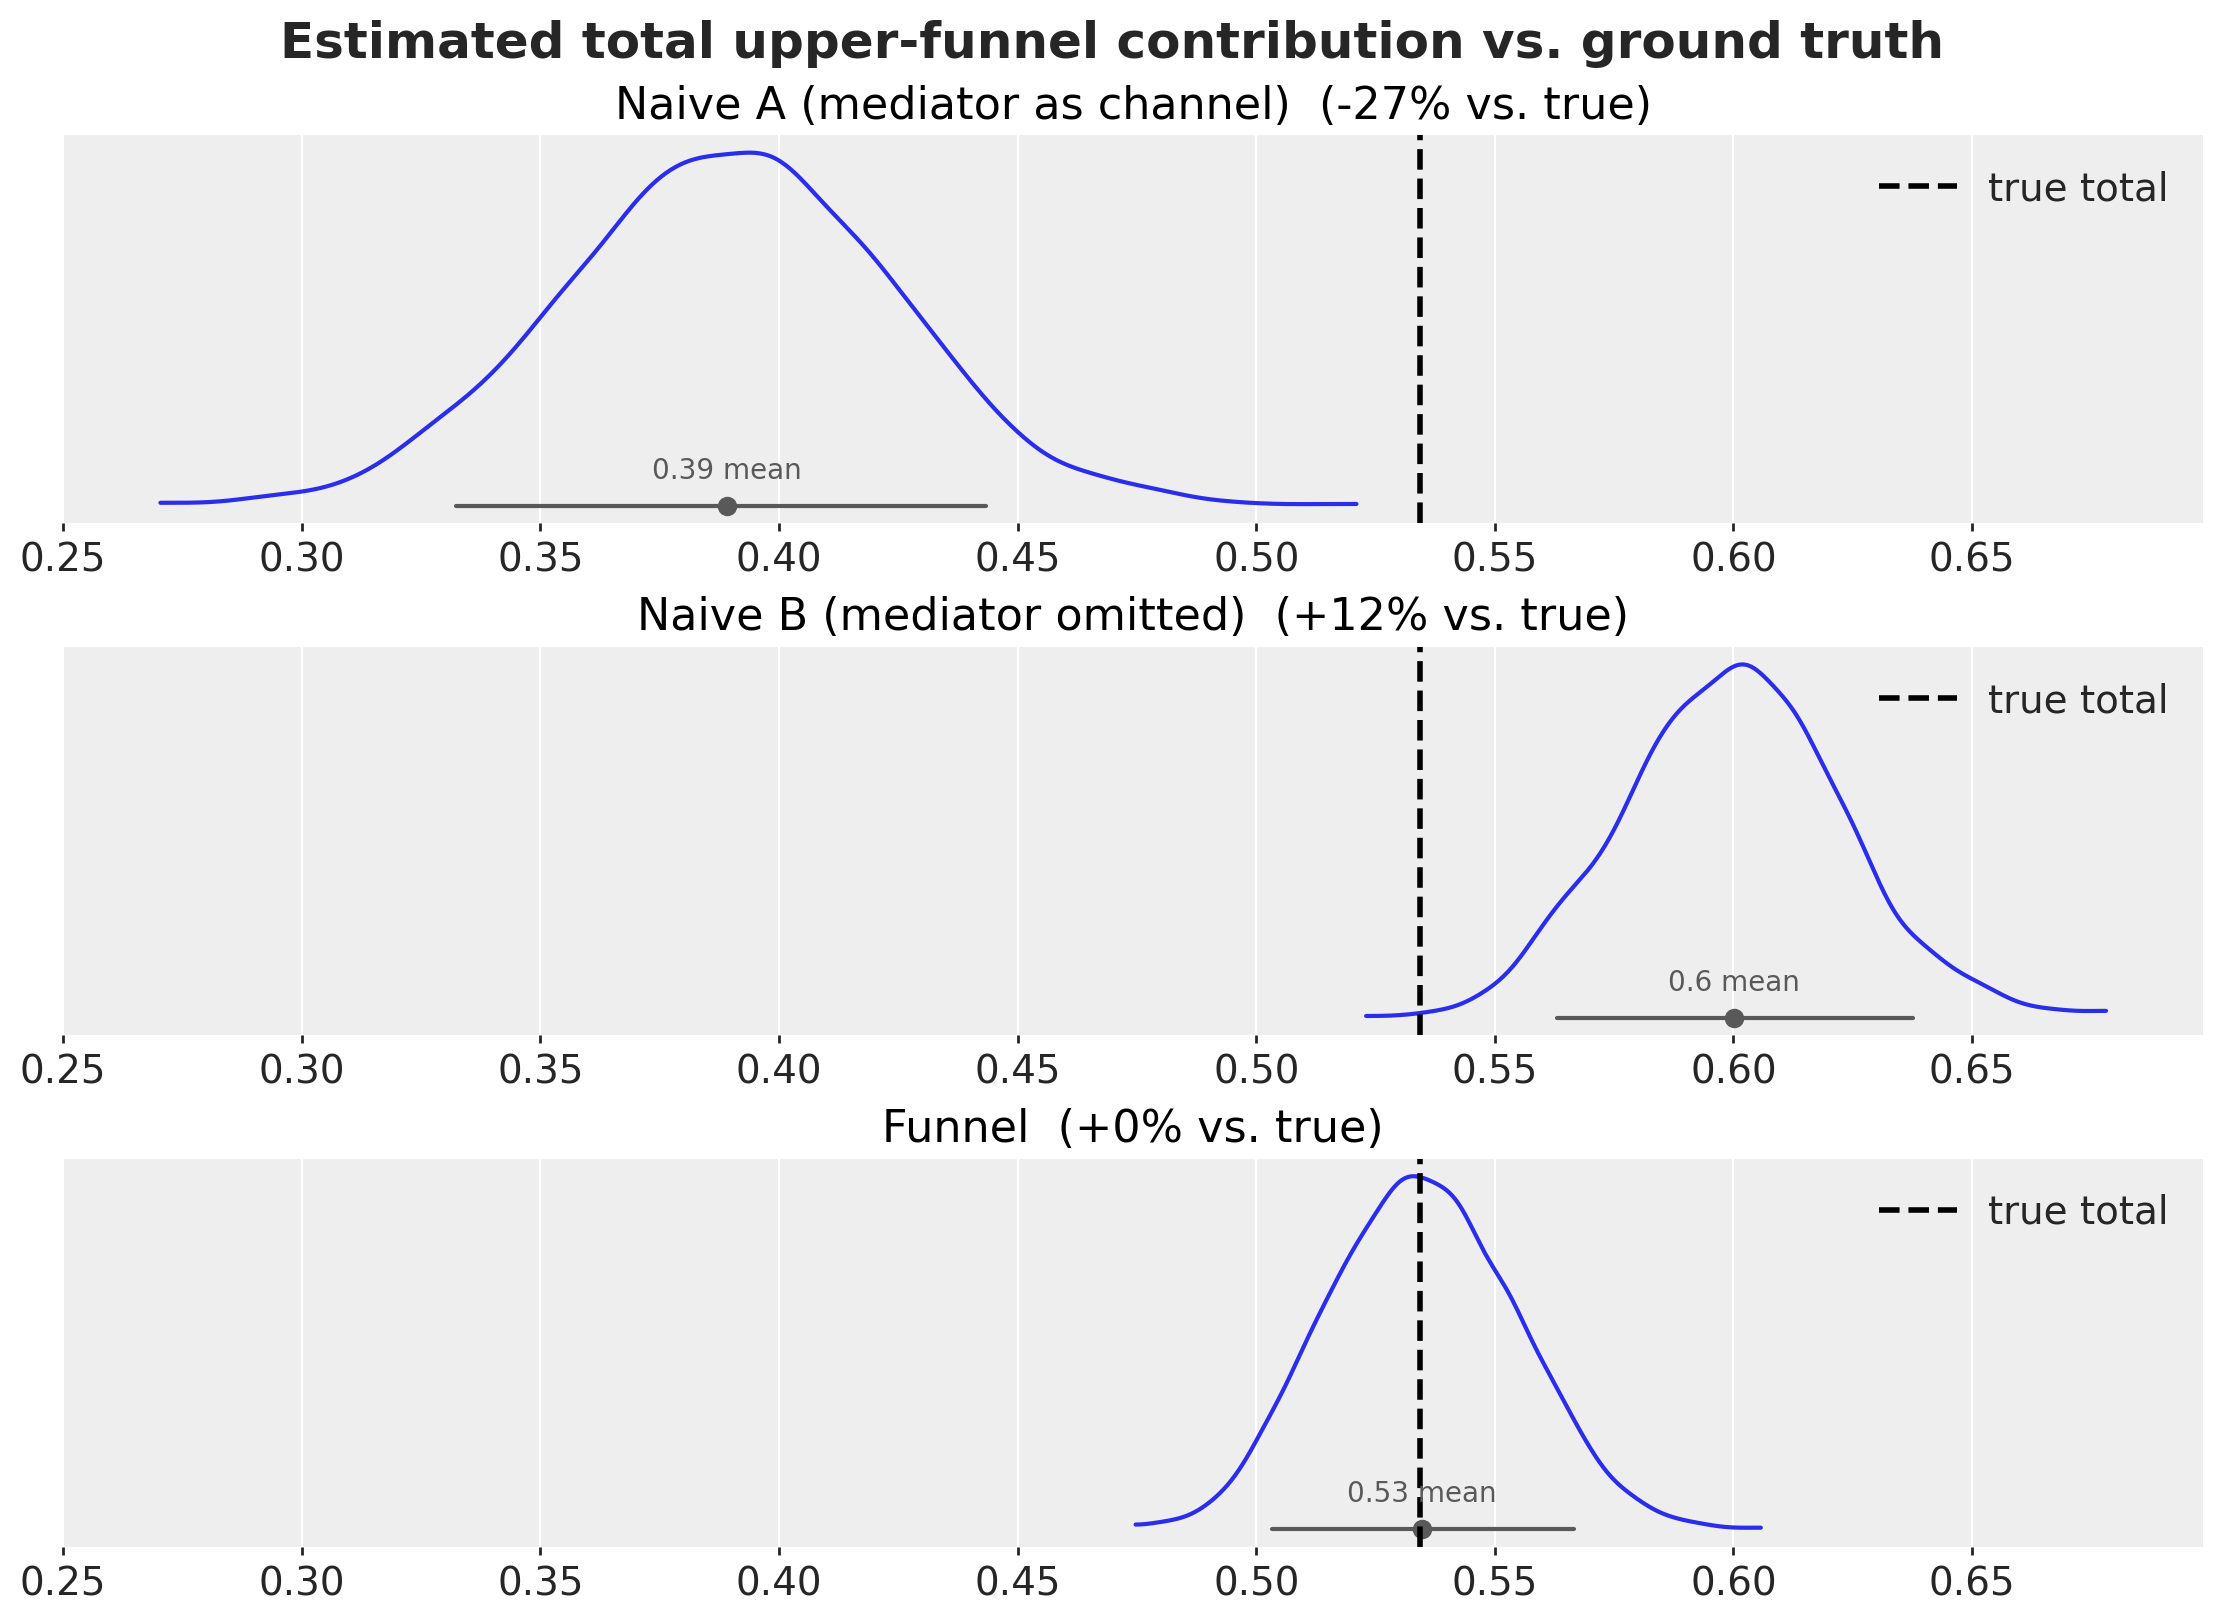

In [28]:
labels = list(estimates)
means = [float(v.mean()) for v in estimates.values()]


def _bare(da):
    """Drop chain/draw coordinate labels so arrays combine positionally."""
    return da.drop_vars([c for c in ("chain", "draw") if c in da.coords])


contrib_ds = xr.Dataset(
    {lab.replace("\n", " "): _bare(da) for lab, da in estimates.items()}
)

pc = azp.plot_dist(
    contrib_ds,
    col_wrap=1,
    figure_kwargs={
        "figsize": (11, 8),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
for ax, name in zip(fig.axes, contrib_ds.data_vars, strict=True):
    ax.axvline(
        true_upper, color="black", linestyle="--", linewidth=2, label="true total"
    )
    bias = float(contrib_ds[name].mean()) / true_upper - 1
    ax.set_title(f"{name}  ({bias:+.0%} vs. true)")
    ax.legend(loc="upper right")
fig.suptitle(
    "Estimated total upper-funnel contribution vs. ground truth",
    fontsize=18,
    fontweight="bold",
);

The two naive models are biased in **opposite directions**: including the mediator
as a channel (Naive A) blocks the indirect path and **understates** the
upper-funnel effect, while omitting it (Naive B) forces a single response curve to
absorb the whole funnel -- direct effect, mediated effect, and the control-driven
lower-funnel demand that upper spend never caused -- which here **overstates** it.
Only the funnel model recovers the true total.

We can also express this as a return-on-ad-spend (ROAS) style ratio -- total
contribution per unit of upper-funnel spend -- since that is the number a budget
allocation keys off. We use the built-in `incrementality` module
(`contribution_over_spend`), which runs an on/off counterfactual on each model's
`channel_contribution`.

One subtlety is itself instructive: the module acts on `channel_contribution`, so
for the funnel model it captures only the **direct** channel and **misses the
mediated path** -- it does not see the `FunnelEffect` subgraph. We therefore report
the funnel model twice: the direct-only ROAS returned by `incrementality`, and the
funnel **total** ROAS (direct plus the counterfactual indirect effect computed
above). The naive models have no mediator subgraph, so their `incrementality` ROAS
is simply what each model attributes to `upper_spend`.

In [29]:
total_upper_spend = df["upper_spend"].sum()


def upper_roas(model):
    """All-time ROAS of upper_spend via the incrementality module."""
    roas = model.incrementality.contribution_over_spend(frequency="all_time")
    return roas.sel(channel="upper_spend")


roas_naive_a = upper_roas(naive_a)
roas_naive_b = upper_roas(naive_b)
# Funnel via incrementality captures the DIRECT channel only (channel_contribution).
roas_funnel_direct = upper_roas(funnel)
# Funnel TOTAL: direct + counterfactual indirect, on the original target scale.
roas_funnel_total = total_post.sum(dim="date") / total_upper_spend

true_roas = float(df["total_upper_true"].sum() / total_upper_spend)
true_direct_roas = float(df["direct_true"].sum() / total_upper_spend)

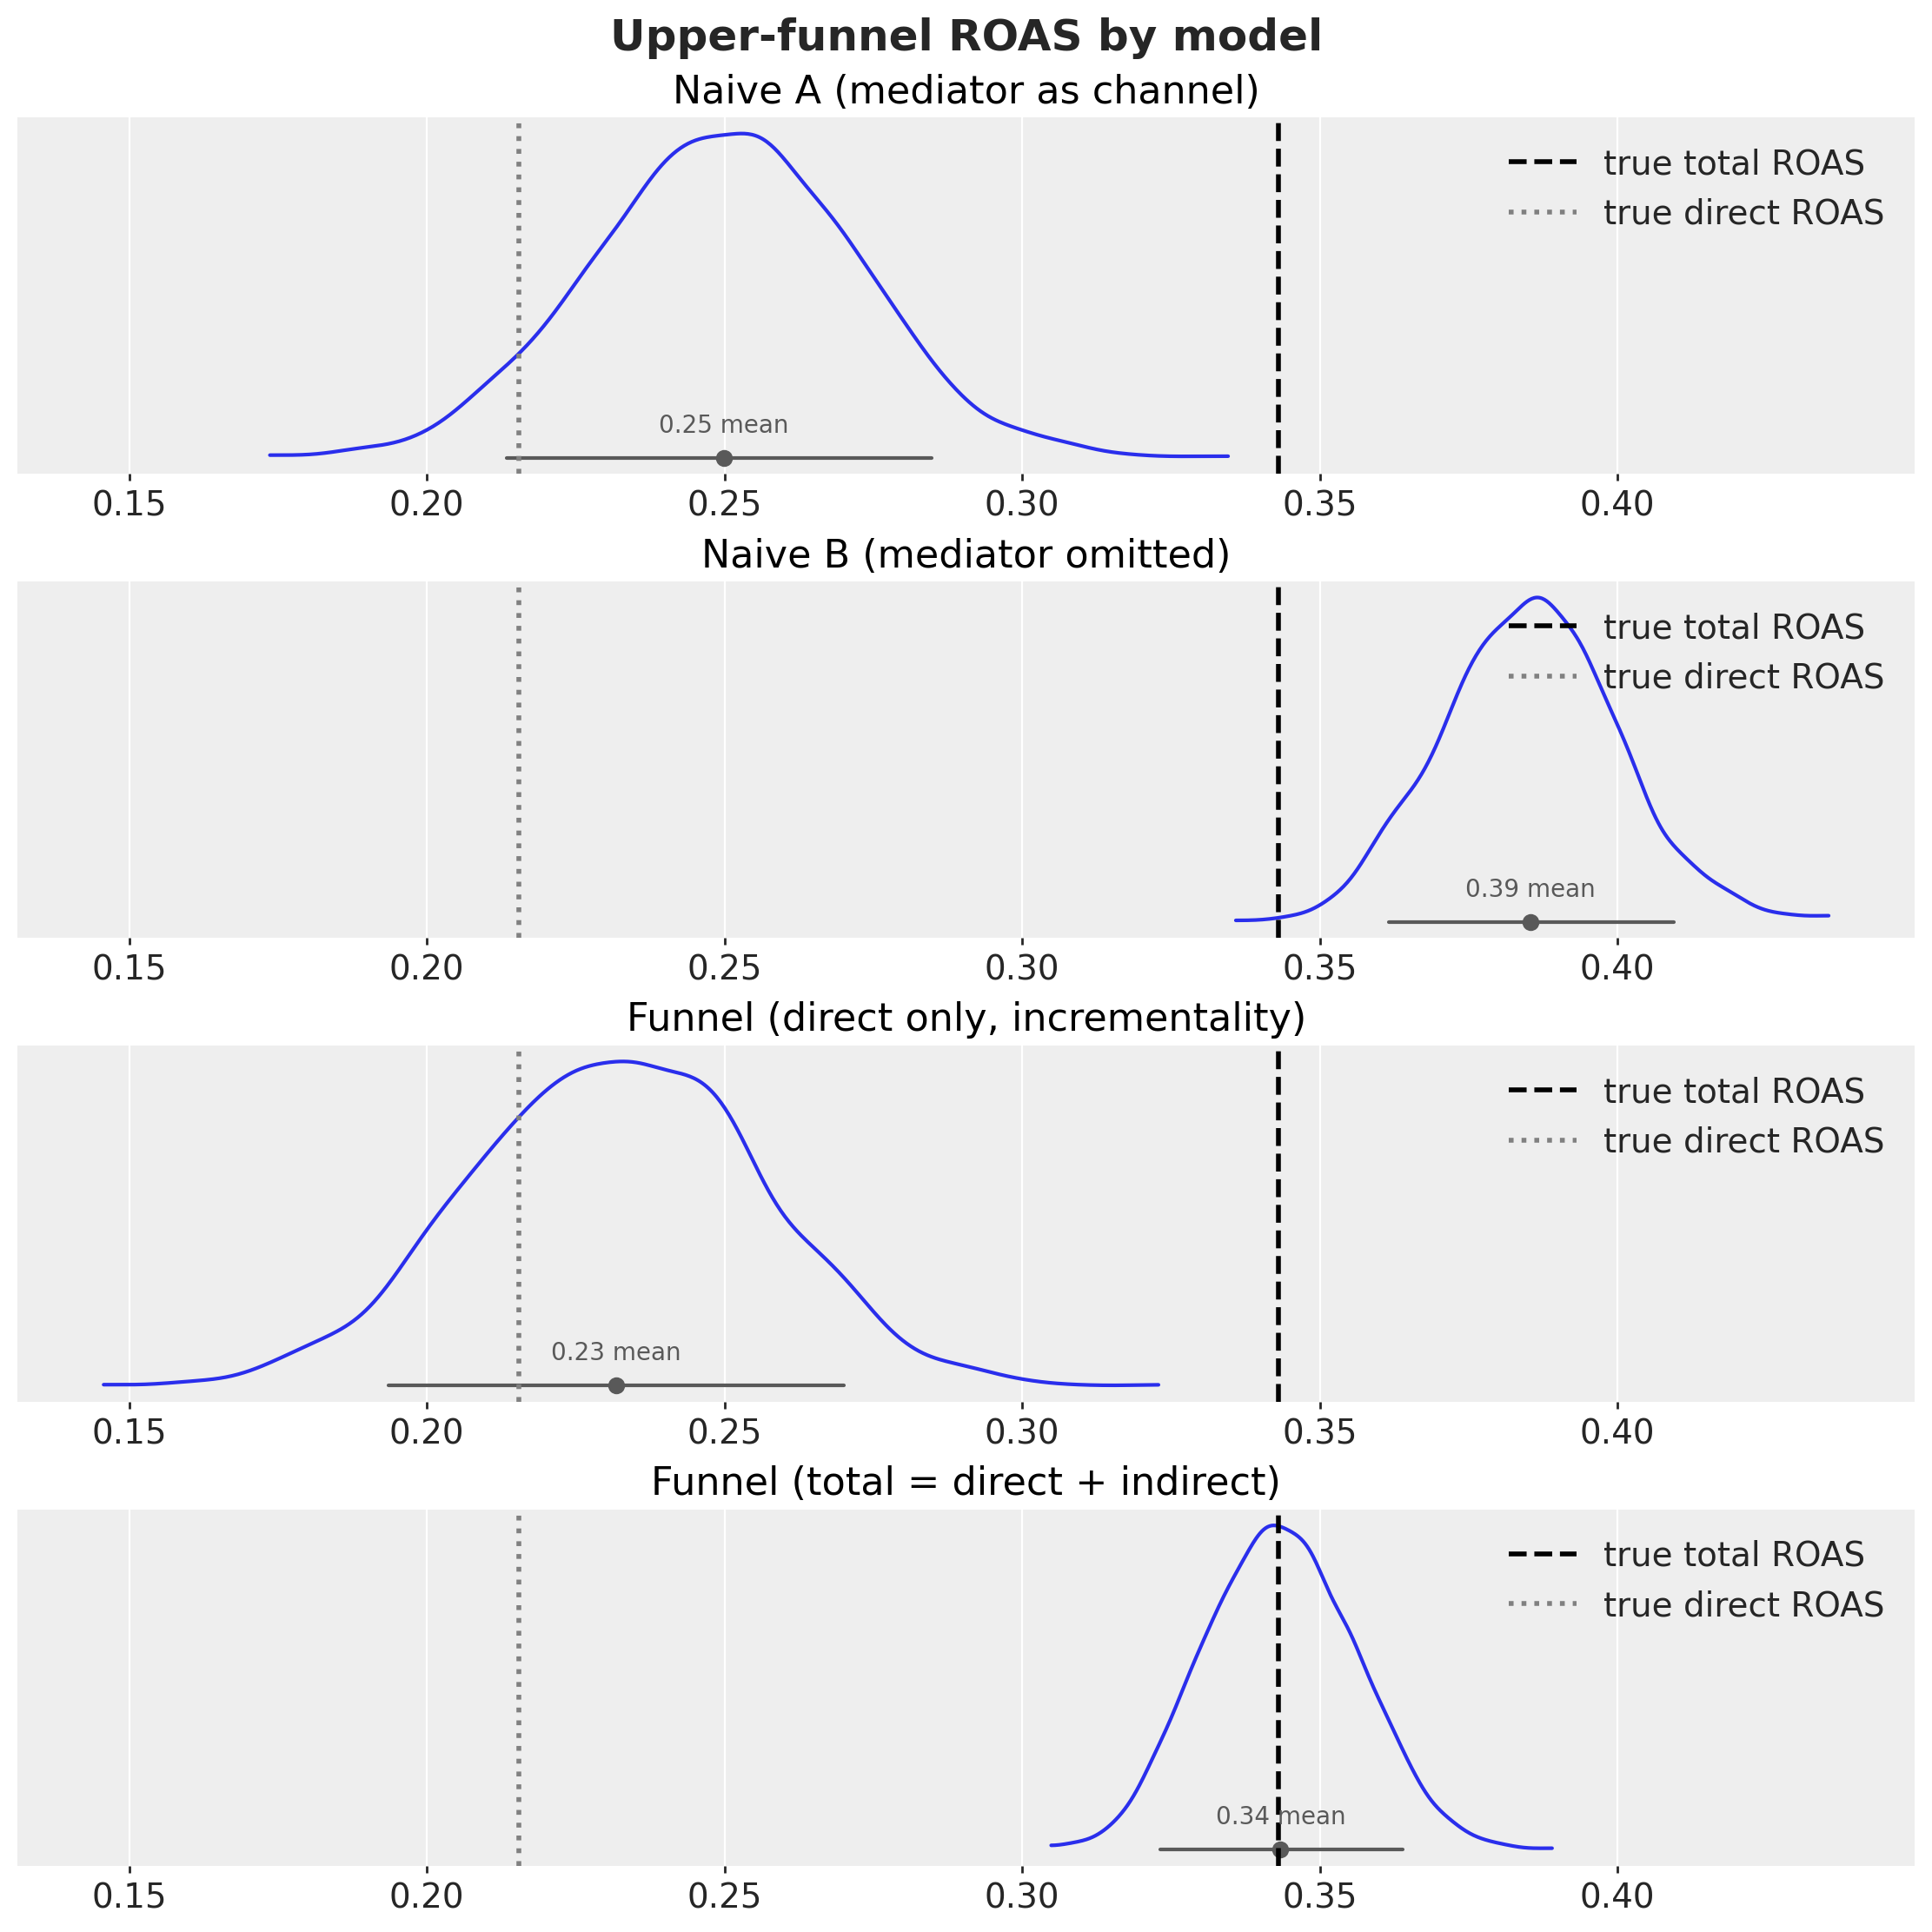

In [30]:
roas_ds = xr.Dataset(
    {
        "Naive A (mediator as channel)": _bare(roas_naive_a),
        "Naive B (mediator omitted)": _bare(roas_naive_b),
        "Funnel (direct only, incrementality)": _bare(roas_funnel_direct),
        "Funnel (total = direct + indirect)": _bare(roas_funnel_total),
    }
)

pc = azp.plot_dist(
    roas_ds,
    col_wrap=1,
    figure_kwargs={
        "figsize": (11, 11),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
for ax, name in zip(fig.axes, roas_ds.data_vars, strict=True):
    ax.axvline(
        true_roas, color="black", linestyle="--", linewidth=2, label="true total ROAS"
    )
    ax.axvline(
        true_direct_roas,
        color="gray",
        linestyle=":",
        linewidth=2,
        label="true direct ROAS",
    )
    ax.set_title(name)
    ax.legend(loc="upper right")
fig.suptitle("Upper-funnel ROAS by model", fontsize=18, fontweight="bold");

In [31]:
roas_by_label = {
    "Naive A (mediator as channel)": float(roas_naive_a.mean()),
    "Naive B (mediator omitted)": float(roas_naive_b.mean()),
    "Funnel": float(roas_funnel_total.mean()),
}

summary = pd.DataFrame(
    {
        "mean_contribution": means,
        "bias_vs_true": [(m - true_upper) / true_upper for m in means],
        "roas": [roas_by_label[lab.replace("\n", " ")] for lab in labels],
    },
    index=[lab.replace("\n", " ") for lab in labels],
)
summary.loc["True"] = [true_upper, 0.0, true_roas]
summary.style.format(
    {"mean_contribution": "{:.3f}", "bias_vs_true": "{:+.1%}", "roas": "{:.3f}"}
)

,mean_contribution,bias_vs_true,roas
Naive A (mediator as channel),0.389,-27.2%,0.250
Naive B (mediator omitted),0.600,+12.3%,0.385
Funnel,0.535,+0.1%,0.343
True,0.534,+0.0%,0.343


### The bias is invisible in predictive fit

Here is the punchline. If we only looked at how well each model fits the target,
we would see almost no difference -- all three achieve a similar in-sample
$R^2$. The bias in the causal estimates does **not** show up as worse predictive
fit, which is exactly why held-out error alone cannot catch it. It only surfaces
once we ask a causal, decision-relevant question.

In [32]:
y_true_vec = df["y_obs"].to_numpy()

r2 = {}
for label, m in [("Naive A", naive_a), ("Naive B", naive_b), ("Funnel", funnel)]:
    # Read the model's own target scale instead of assuming the scaling
    # convention of ``posterior_predictive["y"]``.
    target_scale = float(m.idata.constant_data["target_scale"].squeeze())
    pp = m.idata.posterior_predictive["y"]
    yhat = pp.mean(dim=[d for d in pp.dims if d != "date"]).to_numpy().ravel()
    yhat = yhat * target_scale
    ss_res = ((y_true_vec - yhat) ** 2).sum()
    ss_tot = ((y_true_vec - y_true_vec.mean()) ** 2).sum()
    r2[label] = 1 - ss_res / ss_tot

pd.Series(r2, name="in_sample_R2").to_frame().style.format("{:.4f}")

,in_sample_R2
Naive A,0.9649
Naive B,0.9412
Funnel,0.9675


## Caveats and extensions

This example keeps the funnel deliberately small. A few things to keep in mind
before taking the pattern further:

- **The framework does not "see" the DAG.** The funnel structure lives entirely in
  the `FunnelEffect` code. To the `MMM` object, `funnel_effect_contribution` is
  just one more additive term. The built-in contribution / ROAS decomposition will
  treat it as a flat direct effect unless you post-process it, as we did here by
  computing the indirect path as an explicit counterfactual.
- **Budget optimization.** `pymc-marketing`'s `BudgetOptimizer` does not currently
  substitute its decision variables into `MuEffect` subgraphs, so funnel-aware
  optimization (jointly allocating across funnel layers) is out of scope for this
  notebook.
- **Ordering matters.** An effect that reads another effect's output must be
  appended after it, since `create_effect` runs in list order.
- **Two likelihoods demand careful priors.** The lower-funnel likelihood is very
  informative about the upper-funnel transforms, but it also introduces posterior
  geometry that can slow sampling and weakly identify the direct/indirect split.
  Informative priors and good diagnostics matter more than in a single-likelihood
  MMM.
- **Mind the mediator scale.** The base `MMM` scales its channel to $[0, 1]$, but
  the mediator equation here runs on the raw `lower_spend` / `lower_control`
  series. That is self-consistent because the data is generated in-model, but when
  adapting this to real data note that the second likelihood's $\sigma$ and the
  `HalfNormal(1)` priors on `baseline` / `gamma` live on the *raw* scale of
  lower-funnel spend -- rescale them (or the inputs) accordingly.

Natural extensions of this pattern include **censored** lower-funnel spend (budget
caps, where observed spend understates true demand), **multiple mediators**, and
**time-varying** mediator baselines.

In [33]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 28 Jul 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.14.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

